In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#-----------------------------------------------------------------------------------  인코딩
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

#-----------------------------------------------------------------------------------  정규화
from sklearn.preprocessing import MinMaxScaler,  RobustScaler, StandardScaler
from sklearn.pipeline import Pipeline

#-----------------------------------------------------------------------------------  모델
from sklearn.linear_model import LogisticRegression          # 선형모델
from sklearn.tree import DecisionTreeClassifier              # 트리모델
from sklearn.ensemble import RandomForestClassifier          # 배깅모델   : 데이터N,  똑같은모델N(앙상블)
from lightgbm import LGBMClassifier                          # 부스팅모델 : 데이터1,  다양한모델N(앙상블)
from xgboost import XGBClassifier

#-----------------------------------------------------------------------------------  평가
from sklearn.metrics import accuracy_score,      f1_score,  precision_score , recall_score,         roc_auc_score
from sklearn.metrics import                                 precision_recall_curve,                 roc_curve
from sklearn.metrics import classification_report,          confusion_matrix

#-----------------------------------------------------------------------------------  교차검증
from sklearn.model_selection import train_test_split,                     KFold, StratifiedKFold
from sklearn.model_selection import cross_val_score, cross_validate,      GridSearchCV

import warnings
warnings.filterwarnings('ignore')

sns.set()

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Hancom Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)

In [2]:
df = pd.read_csv("Steel_industry_data.csv")

In [3]:
df.columns = ['date', 'Usage_kWh', 'Lagging_Current_Reactive_Power_kVarh',
               'Leading_Current_Reactive_Power_kVarh', 'CO2_ppm',
               'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
               'WeekStatus', 'Day_of_week', 'Load_Type']

print()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive_Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2_ppm                               35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 
dtypes: float64(6),

<big><b> Attribute Information: </b></big>

<pre>
<b>Date</b>              Continuous-time data taken on the first of the month  
<b>Usage_kWh</b>         Industry Energy Consumption Continuous kWh  
<b>Lagging Current</b>   reactive power Continuous kVarh  
<b>Leading Current</b>   reactive power Continuous kVarh  
<b>CO2_ppm</b>           Continuous ppm  
<b>NSM</b>               Number of Seconds from midnight Continuous S  
<b>Week status</b>       Categorical (Weekend (0) or a Weekday(1))
<b>Day of week</b>       Categorical Sunday, Monday : Saturday  
<b>Load Type</b>         Categorical Light Load, Medium Load, Maximum Load
</pre>

# <b> [Phase 1: 데이터 기초 체력 다지기]

[Phase 1-2] 파이썬 실행 코드 (Feature Engineering)

In [4]:
import pandas as pd
import numpy as np

# 1. 시간 기준 오름차순 정렬 (가장 중요한 선행 작업)
# 'timestamp' 부분은 실제 사용 중인 날짜/시간 컬럼명으로 변경해야 합니다.
df['date'] = pd.to_datetime(df['date'], dayfirst=True)
df = df.sort_values(by='date', ascending=True)

# 2. 기존의 꼬인 인덱스를 완전히 파기하고 순차적인 새 인덱스 부여
df = df.reset_index(drop=True)

In [5]:


# 1. 시간 기반 피처 (NSM 활용)
# 시간 관련 피처 추출 (한국 전력 요금 체계 대응용)
df['Hour'] = df['NSM'] // 3600
df['DayOfWeek'] = df['date'].dt.dayofweek # 0:월, 6:일
df['Month'] = df['date'].dt.month
df['Year'] = df['date'].dt.year
df['Is_Weekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

### [수정] 한전 기준 계절로 매핑
# df['Season'] = df['Month'].map(
#                                     lambda x: 'Spring' if x in [3,4,5]
#                                     else 'Summer' if x in [6,7,8]
#                                     else 'Autumn' if x in [9,10,11]
#                                     else 'Winter'
#                                 )
df['Season'] = df['Month'].map(
                                    lambda x: 'Spring_Fall' if x in [3,4,5, 9, 10]
                                    else 'Summer' if x in [6,7,8]
                                    else 'Winter'
                                )



In [6]:
###[수정] 주, 월에 순환성 부여하는 코드
# 모델링 후에 활용여부 확인필요

cyclic_targets = {'Month': 12, 'DayOfWeek': 7}

for col, period in cyclic_targets.items():
    # 이제 target_df[col]은 확실히 숫자이므로 계산이 가능합니다.
    df[f'{col}_sin'] = np.sin(2 * np.pi * df[col].astype(float) / period)
    df[f'{col}_cos'] = np.cos(2 * np.pi * df[col].astype(float) / period)

print("성공적으로 변환되었습니다. 이제 숫자로 계산된 sin/cos 피처를 확인할 수 있습니다.")

성공적으로 변환되었습니다. 이제 숫자로 계산된 sin/cos 피처를 확인할 수 있습니다.


In [7]:

# 2. 전력 품질 피처 (역률 및 비율)
# 무효전력 합계 (전체 흐르는 전기 에너지의 규모)
### [수정] 컬럼명 추후 활용도 높게 수정
# df['Total_Reactive_Power'] = df['Lagging_Current_Reactive_Power_kVarh'] + df['Leading_Current_Reactive_Power_kVarh']

# 인프라가 감당하는 물리적 부하량 (지상+진상 절대 합계)
df['System_Stress_Load'] = df['Lagging_Current_Reactive_Power_kVarh'] + df['Leading_Current_Reactive_Power_kVarh']

# 유효전력 대비 무효전력 비율 (비효율 지표)
# 0으로 나누기 방지를 위해 작은 값(1e-6) 추가
### [수정] 시각화 진행 시 노이즈 방지를 위해 1e-6 추가 처리.
# Usage_kWh가 0이면 0을 부여, 0이 아니면 계산 수행
# 2. 유효전력 대비 무효전력 집약도 (운영 효율 지표)
# Usage가 0인 구간(비가동)은 0으로 처리하여 시각화 스파이크 방지
df['Reactive_Intensity'] = np.where( df['Usage_kWh'] > 0,  df['System_Stress_Load'] / df['Usage_kWh'], 0)


# # 피타고라스 정리를 이용한 종합 역률 계산
# df['Apparent_Power'] = np.sqrt(df['Usage_kWh']**2 + (df['Lagging_Current_Reactive_Power_kVarh'] - df['Leading_Current_Reactive_Power_kVarh'])**2)
# df['Power_Factor'] = df['Usage_kWh'] / (df['Apparent_Power'] + 1e-6)
### [수정] 역률지표의 구분, 1-6승에 대한 부분 처리
# 순무효전력 기반 물리적 역률
df['Apparent_Power'] = np.sqrt(df['Usage_kWh']**2 + (df['Lagging_Current_Reactive_Power_kVarh'] - df['Leading_Current_Reactive_Power_kVarh'])**2)
df['PF_Physical'] = np.where(df['Apparent_Power'] > 0, df['Usage_kWh'] / df['Apparent_Power'], 1.0)


# 3. 변동성 및 추세 피처
# 시계열 데이터이므로 순서대로 정렬되어 있다고 가정
### [수정] 모델을 시계열로 돌리지 않는 상황이므로 전력 사용량에 대한 피쳐는 삭제(다중공선성 우려)
# df['Usage_Moving_Avg_1h_mean'] = df['Usage_kWh'].rolling(window=4).mean() # 1시간(15분*4) 이동평균
# 전력 사용의 흔들림에 대한 내용이므로 유지
df['Motor_Moving_Avg_1h_std'] = df['Usage_kWh'].rolling(window=4, min_periods=2).std().bfill() # 1시간(15분*4) 이동평균 표준편차


print("파생 피처 생성 완료. 상위 5개 행 확인:")
print(df.head())

파생 피처 생성 완료. 상위 5개 행 확인:
                 date  Usage_kWh  Lagging_Current_Reactive_Power_kVarh  \
0 2018-01-01 00:00:00       3.42                                  3.46   
1 2018-01-01 00:15:00       3.17                                  2.95   
2 2018-01-01 00:30:00       4.00                                  4.46   
3 2018-01-01 00:45:00       3.24                                  3.28   
4 2018-01-01 01:00:00       3.31                                  3.56   

   Leading_Current_Reactive_Power_kVarh  CO2_ppm  \
0                                   0.0      0.0   
1                                   0.0      0.0   
2                                   0.0      0.0   
3                                   0.0      0.0   
4                                   0.0      0.0   

   Lagging_Current_Power_Factor  Leading_Current_Power_Factor   NSM  \
0                         70.30                         100.0     0   
1                         73.21                         100.0   900   
2   

<Figure size 1200x600 with 0 Axes>

<Axes: xlabel='Usage_kWh', ylabel='CO2_ppm'>

Text(0.5, 1.0, 'Critical Flaw 1: Power Usage vs CO2 by Day of Week')

Text(0.5, 0, 'Usage_kWh (Physical Truth)')

Text(0, 0.5, 'CO2_ppm (Sensor Data)')

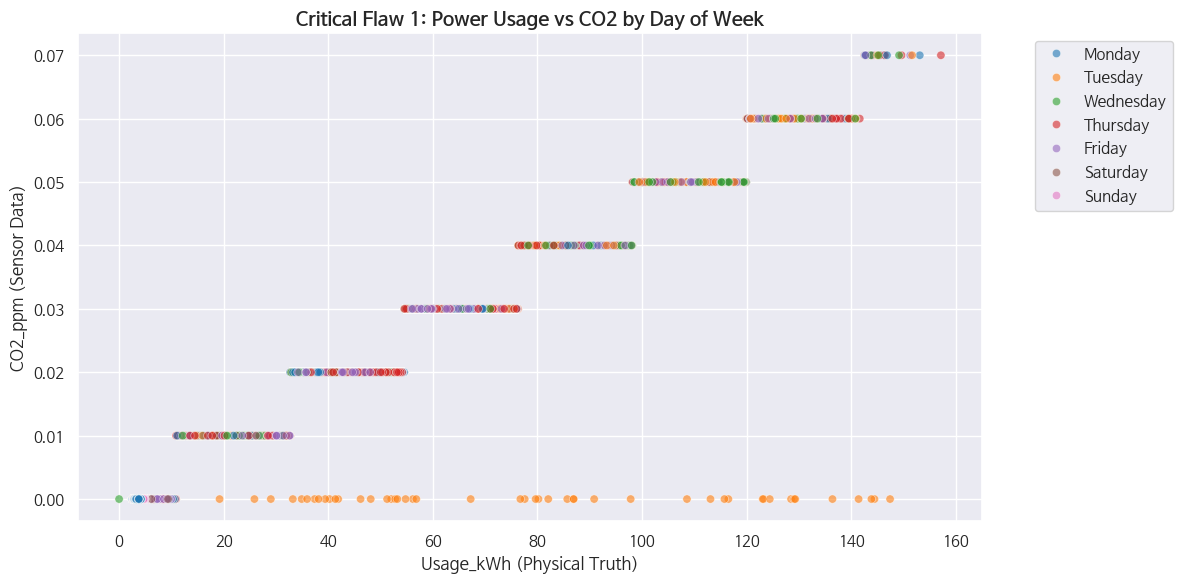

▶ 가동 중(전력 10kWh 이상) 요일별 CO2 결측 비율(%)
Day_of_week  Zero_CO2_Percentage
    Tuesday             2.212389
     Sunday             1.289134
   Saturday             0.298285
     Monday             0.287711
   Thursday             0.274402
  Wednesday             0.260191
     Friday             0.201532
--------------------------------------------------


<Figure size 1200x600 with 0 Axes>

<Axes: xlabel='Usage_kWh', ylabel='CO2_ppm'>

Text(0.5, 1.0, 'Critical Flaw 2: Power Usage vs CO2 by Month (Focus on January)')

Text(0.5, 0, 'Usage_kWh (Physical Truth)')

Text(0, 0.5, 'CO2_ppm (Sensor Data)')

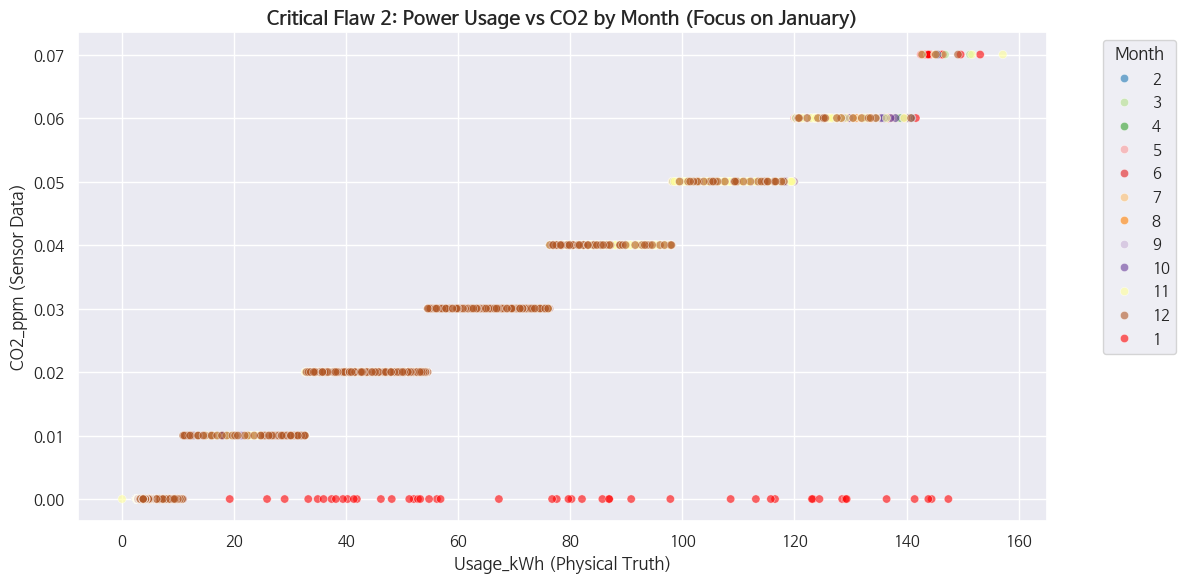

▶ 가동 중(전력 10kWh 이상) 월별 CO2 결측 비율(%)
 Month  Zero_CO2_Percentage
     1             3.196622
    12             0.564334
     9             0.526870
    10             0.397456
     6             0.381316
     4             0.337268
     2             0.327332
     3             0.240192
     8             0.199005
     5             0.176523
    11             0.159236
     7             0.155039
--------------------------------------------------


Text(0, 0.5, 'Usage_kWh (Blue)')

Text(0, 0.5, 'CO2_ppm (Red)')

Text(0.5, 1.0, 'Time-Series Proof: January Sensor Failure (Power Spikes, but CO2 Flatlines)')

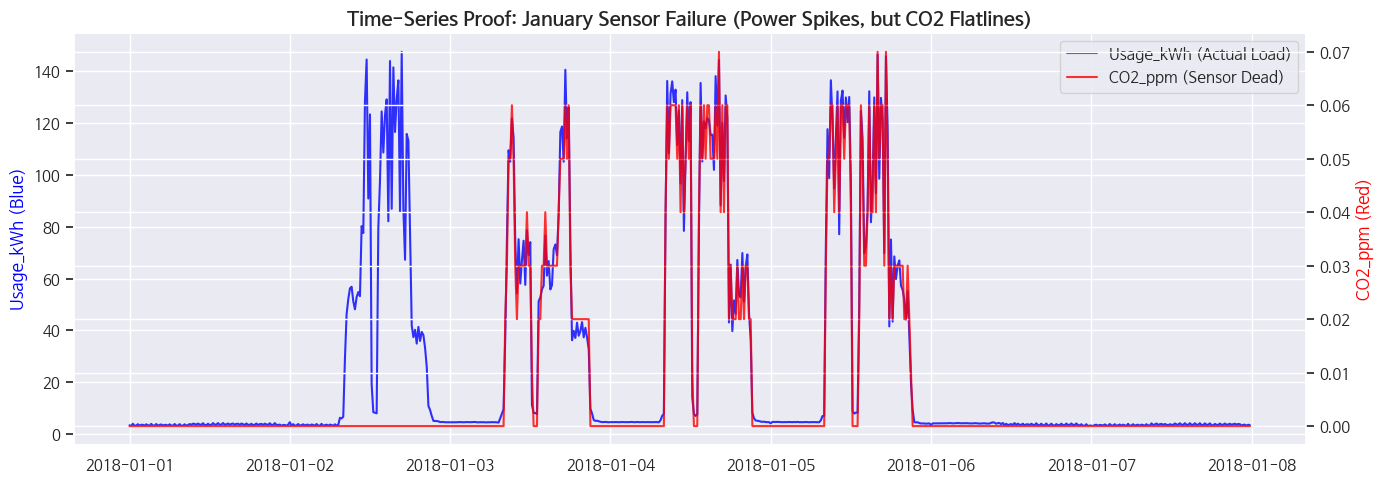

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. 요일별 물리적 모순 시각화 및 통계 (기존 코드 유지)
# =====================================================================
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='Usage_kWh', y='CO2_ppm', hue='Day_of_week', palette='tab10', alpha=0.6)
plt.title('Critical Flaw 1: Power Usage vs CO2 by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Usage_kWh (Physical Truth)')
plt.ylabel('CO2_ppm (Sensor Data)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

active_df = df[df['Usage_kWh'] > 10.0]
zero_co2_day = active_df.groupby('Day_of_week').apply(
    lambda x: (x['CO2_ppm'] == 0).sum() / len(x) * 100
).reset_index(name='Zero_CO2_Percentage')

print("▶ 가동 중(전력 10kWh 이상) 요일별 CO2 결측 비율(%)")
print(zero_co2_day.sort_values(by='Zero_CO2_Percentage', ascending=False).to_string(index=False))
print("-" * 50)

# =====================================================================
# 2. 월별 물리적 모순 시각화 및 통계 (1월 집중 노이즈 증명)
# =====================================================================
# 12개의 색상을 지원하는 Paired 팔레트 로드
base_colors = sns.color_palette("Paired", 12)

# 1~12월에 색상 매핑
custom_palette = {m: base_colors[i] for i, m in enumerate(range(1, 13))}

# 1월의 색상만 튀는 색으로 강제 변경
custom_palette[1] = '#FF0000' # 강렬한 빨간색 지정

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df, 
    x='Usage_kWh', 
    y='CO2_ppm', 
    hue='Month', 
    palette=custom_palette, 
    alpha=0.6,
    hue_order=[m for m in range(2, 13)] + [1]
)

plt.title('Critical Flaw 2: Power Usage vs CO2 by Month (Focus on January)', fontsize=14, fontweight='bold')
plt.xlabel('Usage_kWh (Physical Truth)')
plt.ylabel('CO2_ppm (Sensor Data)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Month')
plt.tight_layout()
plt.show()
zero_co2_month = active_df.groupby('Month').apply(
    lambda x: (x['CO2_ppm'] == 0).sum() / len(x) * 100
).reset_index(name='Zero_CO2_Percentage')

print("▶ 가동 중(전력 10kWh 이상) 월별 CO2 결측 비율(%)")
print(zero_co2_month.sort_values(by='Zero_CO2_Percentage', ascending=False).to_string(index=False))
print("-" * 50)

# =====================================================================
# 3. 1월 시계열의 치명적 붕괴 증명 (Time-Series Proof)
# =====================================================================
# 1월 데이터 중 문제가 되었던 첫째 주(약 1주일 치, 672행)만 필터링
jan_sample = df[df['Month'] == 1].sort_values('date').head(672)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

# 실제 공정 부하 (전력)
ax1.plot(jan_sample['date'], jan_sample['Usage_kWh'], color='blue', label='Usage_kWh (Actual Load)', alpha=0.8)
# 죽어버린 센서 데이터 (CO2)
ax2.plot(jan_sample['date'], jan_sample['CO2_ppm'], color='red', label='CO2_ppm (Sensor Dead)', alpha=0.8)

ax1.set_ylabel('Usage_kWh (Blue)', color='blue')
ax2.set_ylabel('CO2_ppm (Red)', color='red')
plt.title('Time-Series Proof: January Sensor Failure (Power Spikes, but CO2 Flatlines)', fontsize=14, fontweight='bold')

# 두 축의 범례를 하나로 묶어서 표시
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

plt.tight_layout()
plt.show()

이 코드를 실행하면 세 번째 시계열 그래프에서 파란색 선(전력)은 140kWh까지 미친 듯이 솟구치며 기계가 가동됨을 외치고 있는데, 빨간색 선(CO2)은 바닥(0)에 시체처럼 누워있는 충격적인 대비를 육안으로 확인할 수 있습니다.

센서 통신 시스템의 구조적 결측(Systematic Bias)이 1월과 화요일에 집중적으로 발생함을 시각적/통계적으로 교차 검증하였고, 이에 따라 해당 파생 변수를 모델에서 영구 제명했습니다"**라고 말하는 것은 완벽한 데이터 엔지니어의 논리입니다.

In [9]:

# ---------------------------------
# 1️⃣ 역률 및 무효전력 파생 변수 생성
# ---------------------------------

# 모터 가동 비중 (%) 계산
# 데이터셋 전체에서의 최대 지상 무효전력을 '모터 100% 가동' 상태로 가정
max_lagging = df['Lagging_Current_Reactive_Power_kVarh'].max()
df['Motor_Operating_Rate'] = (df['Lagging_Current_Reactive_Power_kVarh'] / max_lagging) * 100

# 커패시터 가동 비중 (%) 계산
# 최대 진상 무효전력을 '커패시터 100% 가동' 상태로 가정
max_leading = df['Leading_Current_Reactive_Power_kVarh'].max()
df['Capacitor_Operating_Rate'] = (df['Leading_Current_Reactive_Power_kVarh'] / max_leading) * 100

# 무효전력 총량 및 활성비
df['Q_total_abs'] = ( df['Lagging_Current_Reactive_Power_kVarh']
                      + df['Leading_Current_Reactive_Power_kVarh'] )

df['Motor_Ratio'] = ( df['Lagging_Current_Reactive_Power_kVarh'] / df['Q_total_abs'] )

df['Capacitor_Ratio'] = ( df['Leading_Current_Reactive_Power_kVarh'] / df['Q_total_abs'] )


# 콘덴서 과보상 의심 구간
df['Over_Correction_Flag'] = ( (df['Capacitor_Ratio'] > 0.6) & (df['PF_Physical'] > 0.98) )


In [10]:
##생산량 가정 피처

# 1. 동적 임계치 산출

conditions = [
    (df['Motor_Operating_Rate'] <= 1.0),  # 0: OFF (모터가 거의 정지)
    (df['Motor_Operating_Rate'] > 5.0)    # 2: Production (모터가 일정 수준 이상 가동)
]

choices = [0, 2] # 0: OFF, 2: Production, 1: Wait/Idle

# 3. 새로운 피처 적용
df['Is_Operating_Flag'] = np.select(conditions, choices, default=1)

# 4. 검증: 각 상태별 전력 사용량 통계 확인
status_summary = df.groupby('Is_Operating_Flag')['Usage_kWh'].agg(['count', 'mean', 'max'])
print("\n[Op_Status별 통계 요약]")
print(status_summary)




[Op_Status별 통계 요약]
                   count       mean     max
Is_Operating_Flag                          
0                   7917   6.998344   42.66
1                   8784   6.106223   76.28
2                  18339  46.381687  157.18


<Figure size 1000x600 with 0 Axes>

<Axes: xlabel='Usage_kWh', ylabel='Density'>

Text(0.5, 1.0, 'Distribution of Usage_kWh by Is_Operating Status')

Text(0.5, 0, 'Usage_kWh')

Text(0, 0.5, 'Density')

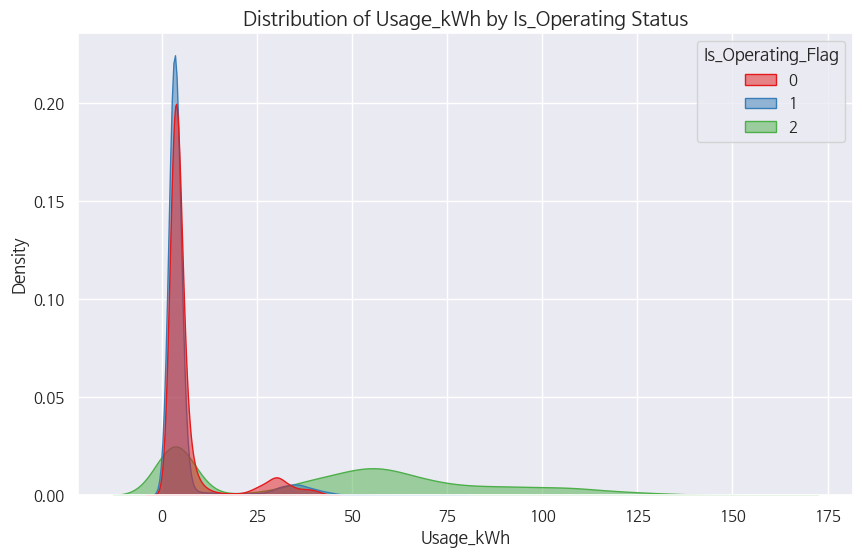

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Usage_kWh')

Text(0, 0.5, 'Is_Operating (0 or 1)')

Text(0.5, 1.0, 'Time-Series Alignment: 1 (Usage vs Operating Flag)')

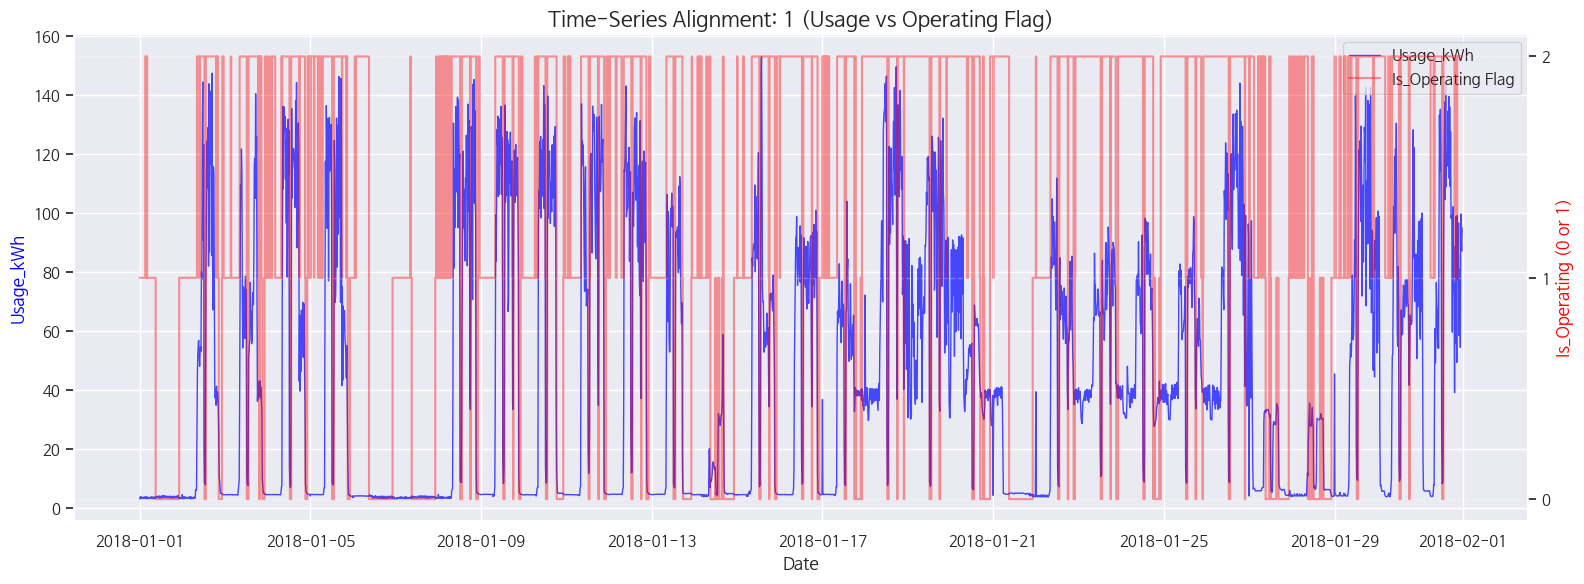

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Usage_kWh')

Text(0, 0.5, 'Is_Operating (0 or 1)')

Text(0.5, 1.0, 'Time-Series Alignment: 2 (Usage vs Operating Flag)')

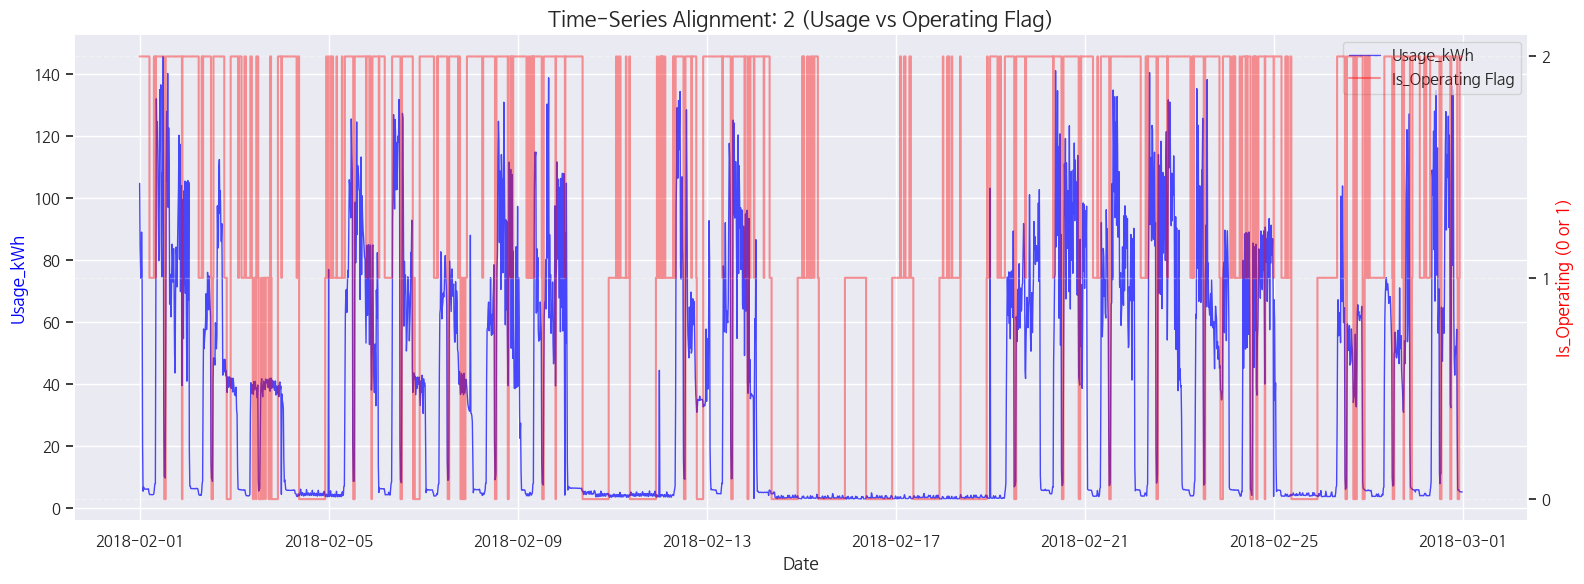

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Usage_kWh')

Text(0, 0.5, 'Is_Operating (0 or 1)')

Text(0.5, 1.0, 'Time-Series Alignment: 3 (Usage vs Operating Flag)')

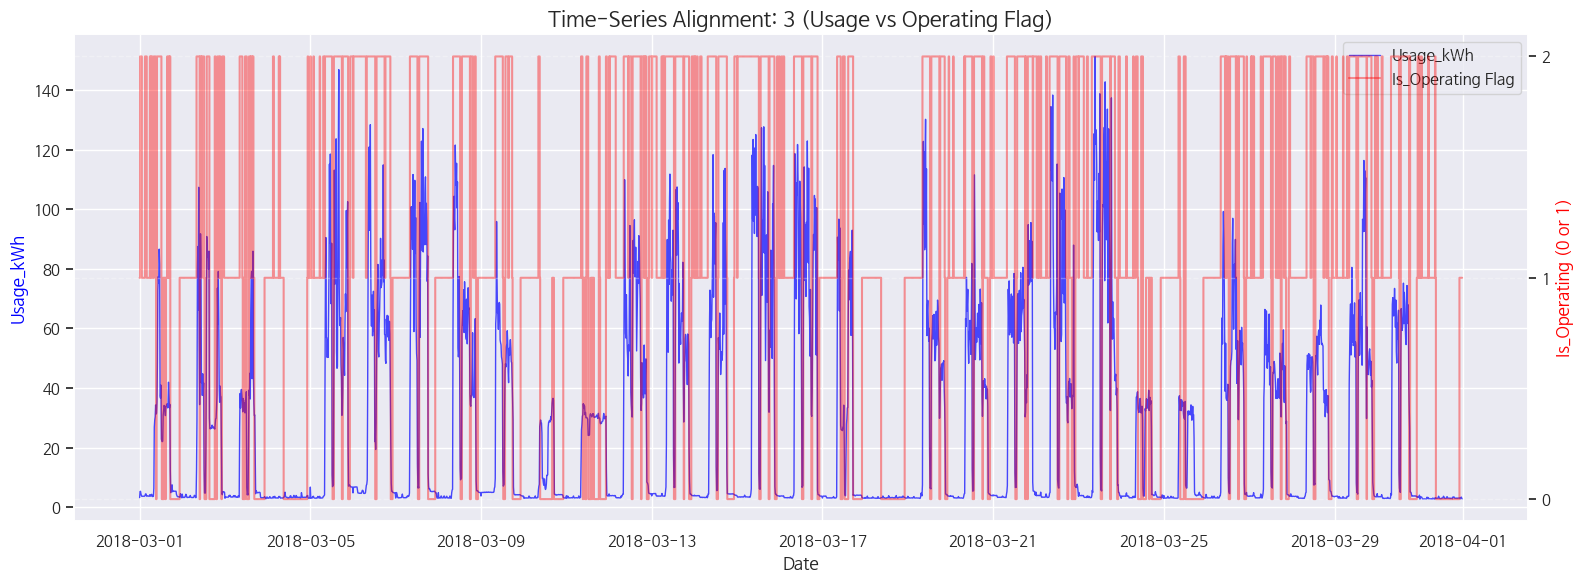

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Usage_kWh')

Text(0, 0.5, 'Is_Operating (0 or 1)')

Text(0.5, 1.0, 'Time-Series Alignment: 4 (Usage vs Operating Flag)')

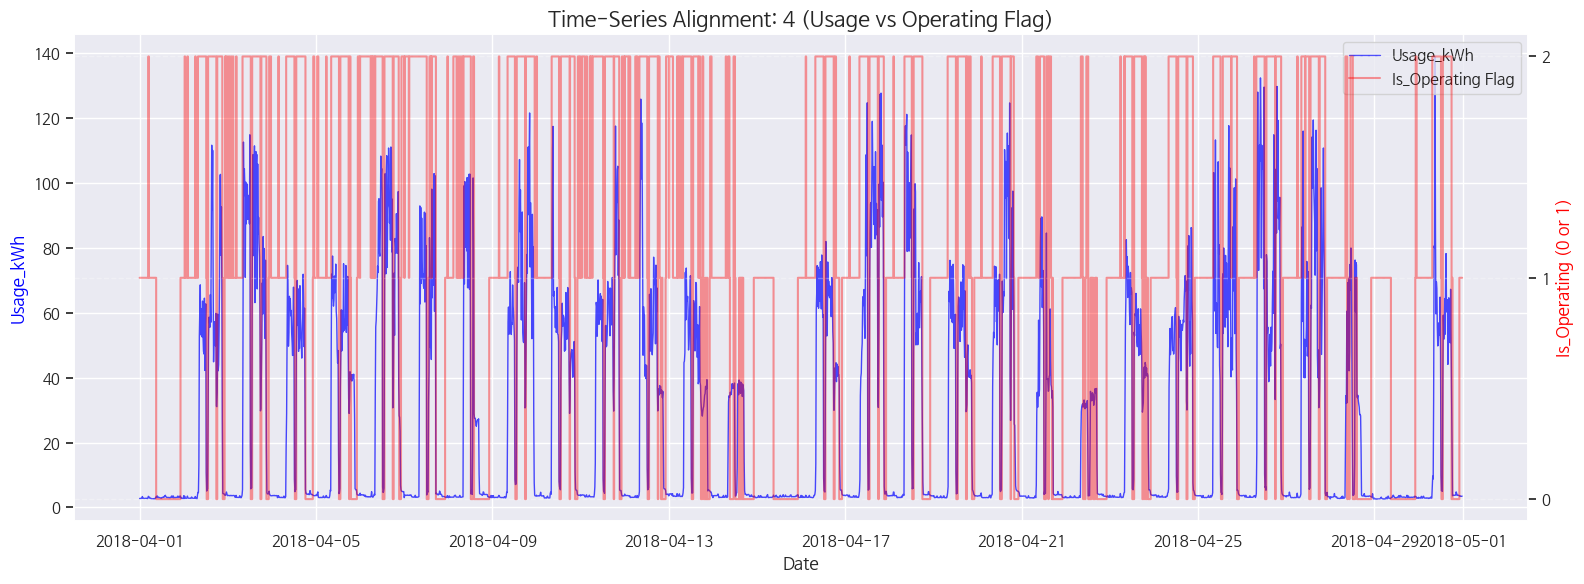

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Usage_kWh')

Text(0, 0.5, 'Is_Operating (0 or 1)')

Text(0.5, 1.0, 'Time-Series Alignment: 5 (Usage vs Operating Flag)')

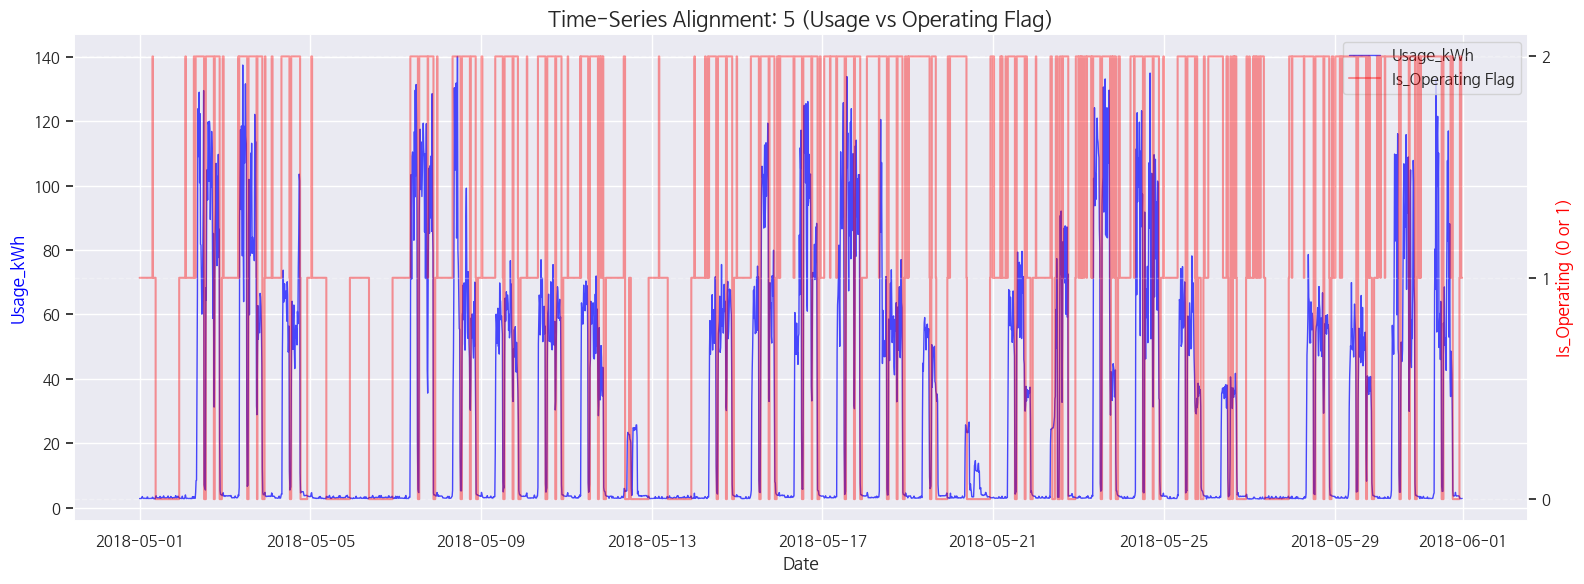

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Usage_kWh')

Text(0, 0.5, 'Is_Operating (0 or 1)')

Text(0.5, 1.0, 'Time-Series Alignment: 6 (Usage vs Operating Flag)')

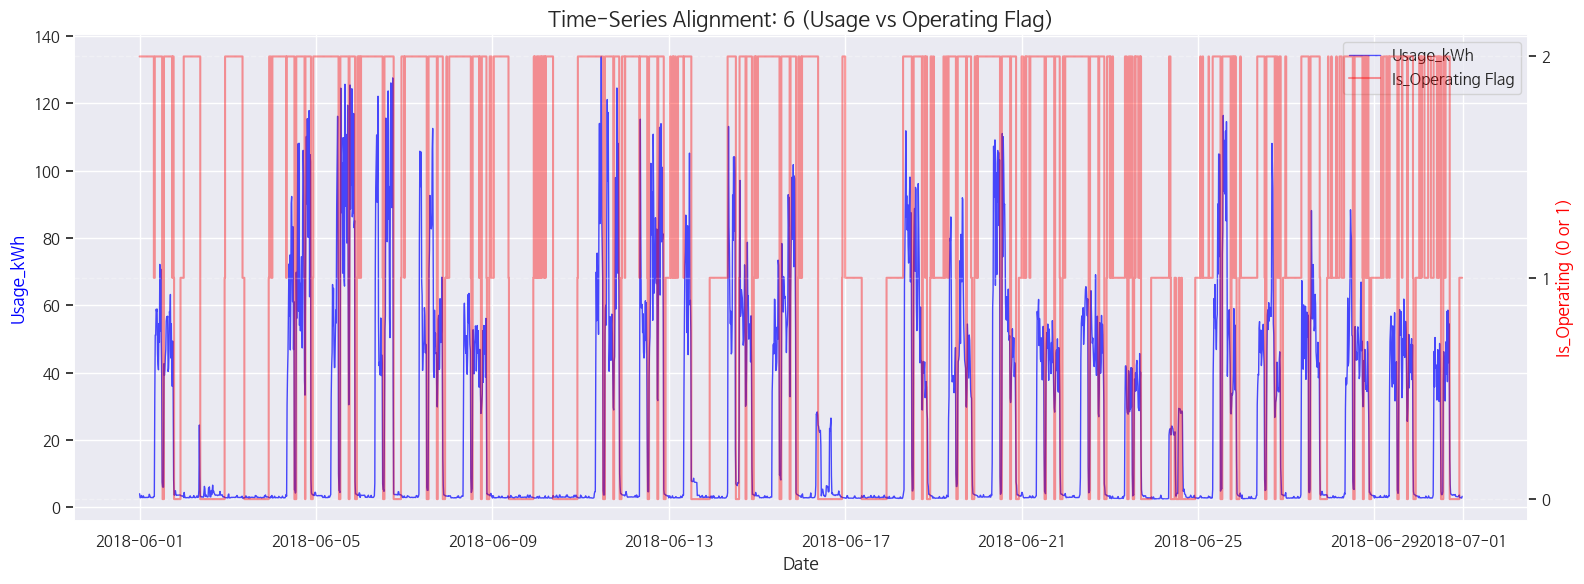

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Usage_kWh')

Text(0, 0.5, 'Is_Operating (0 or 1)')

Text(0.5, 1.0, 'Time-Series Alignment: 7 (Usage vs Operating Flag)')

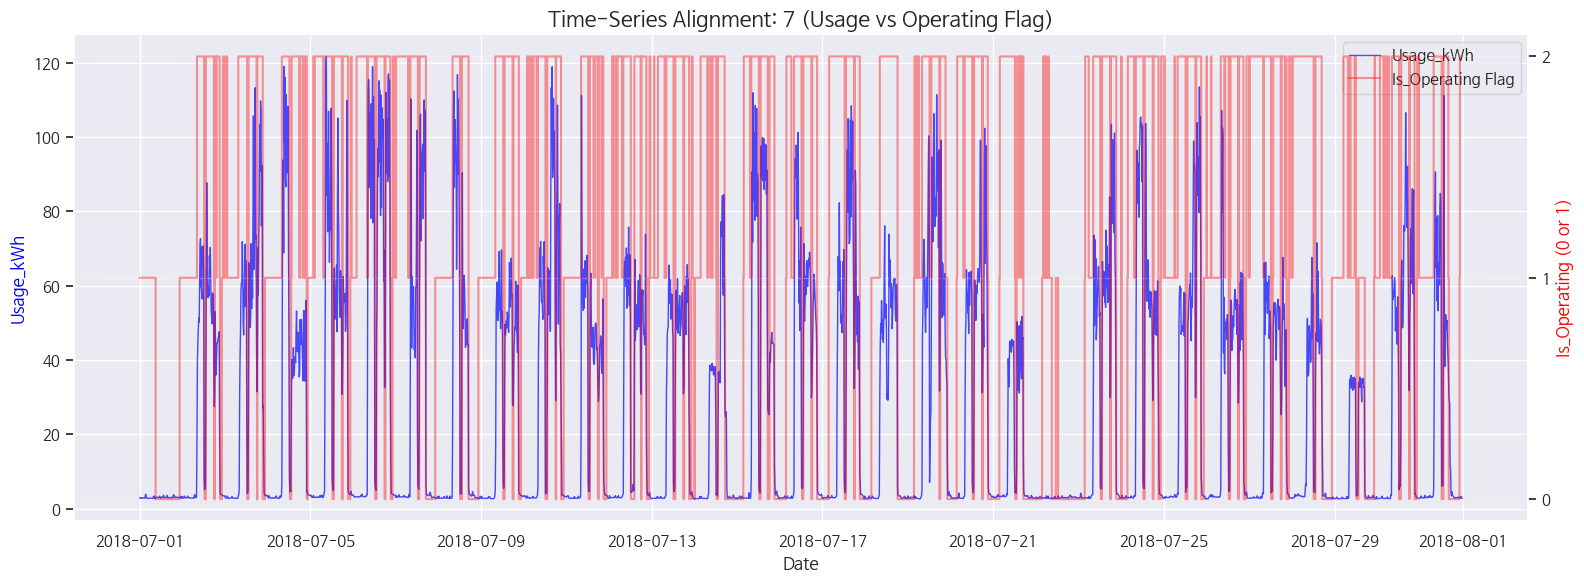

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Usage_kWh')

Text(0, 0.5, 'Is_Operating (0 or 1)')

Text(0.5, 1.0, 'Time-Series Alignment: 8 (Usage vs Operating Flag)')

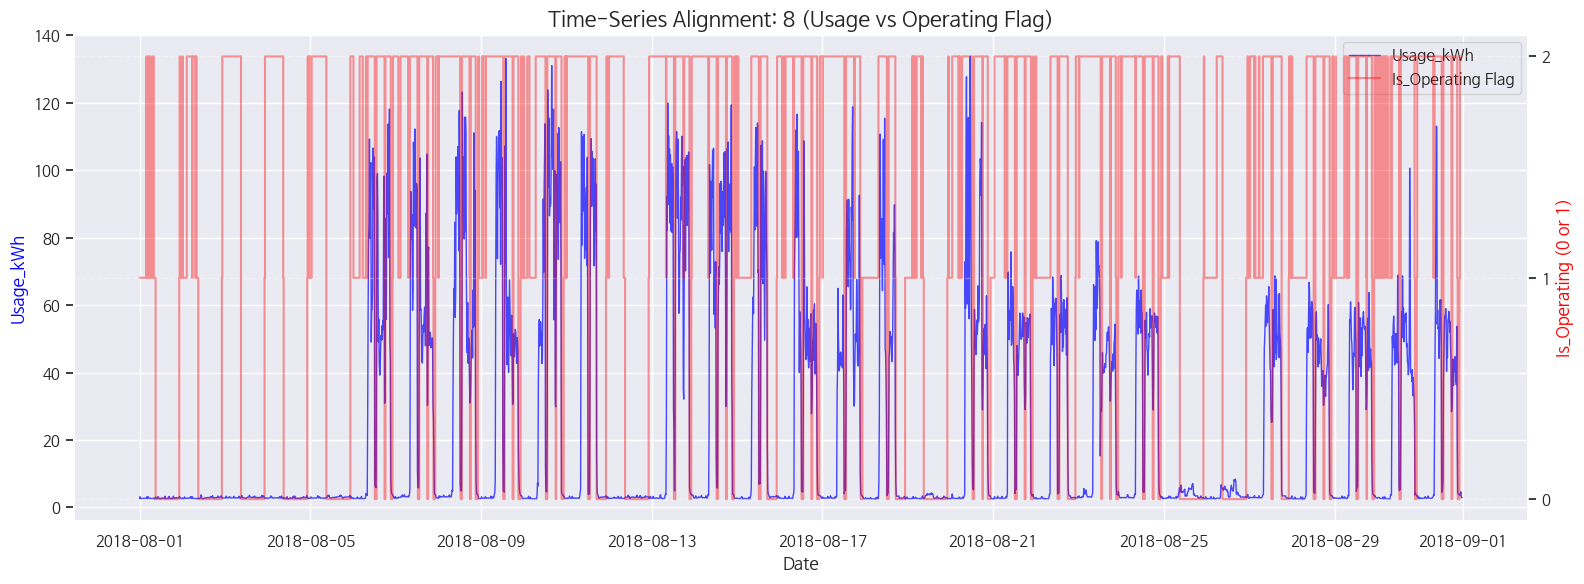

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Usage_kWh')

Text(0, 0.5, 'Is_Operating (0 or 1)')

Text(0.5, 1.0, 'Time-Series Alignment: 9 (Usage vs Operating Flag)')

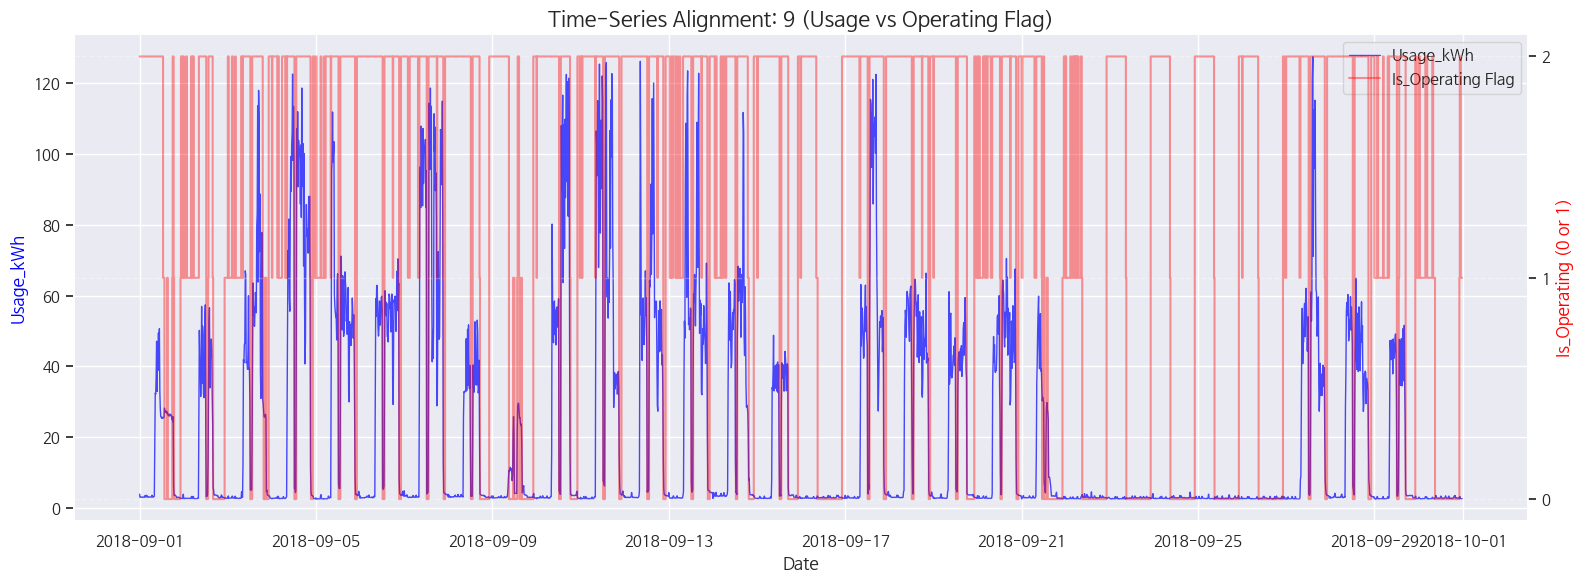

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Usage_kWh')

Text(0, 0.5, 'Is_Operating (0 or 1)')

Text(0.5, 1.0, 'Time-Series Alignment: 10 (Usage vs Operating Flag)')

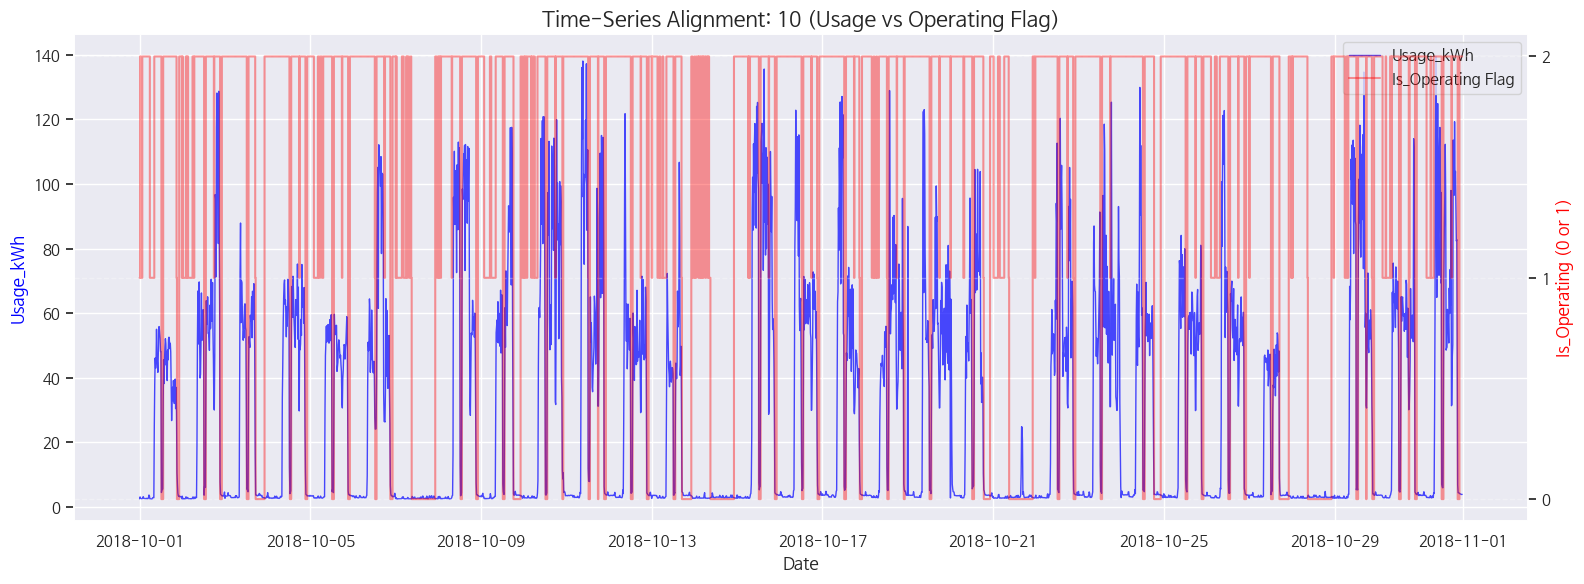

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Usage_kWh')

Text(0, 0.5, 'Is_Operating (0 or 1)')

Text(0.5, 1.0, 'Time-Series Alignment: 11 (Usage vs Operating Flag)')

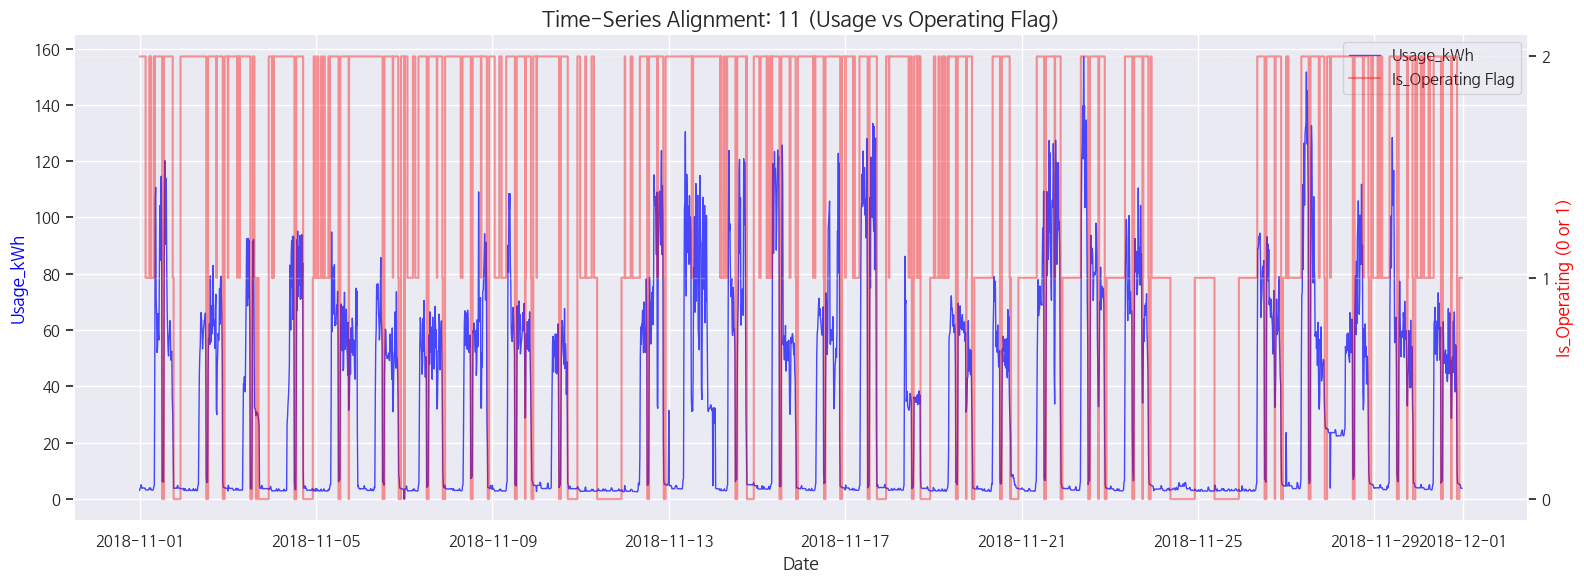

Text(0.5, 0, 'Date')

Text(0, 0.5, 'Usage_kWh')

Text(0, 0.5, 'Is_Operating (0 or 1)')

Text(0.5, 1.0, 'Time-Series Alignment: 12 (Usage vs Operating Flag)')

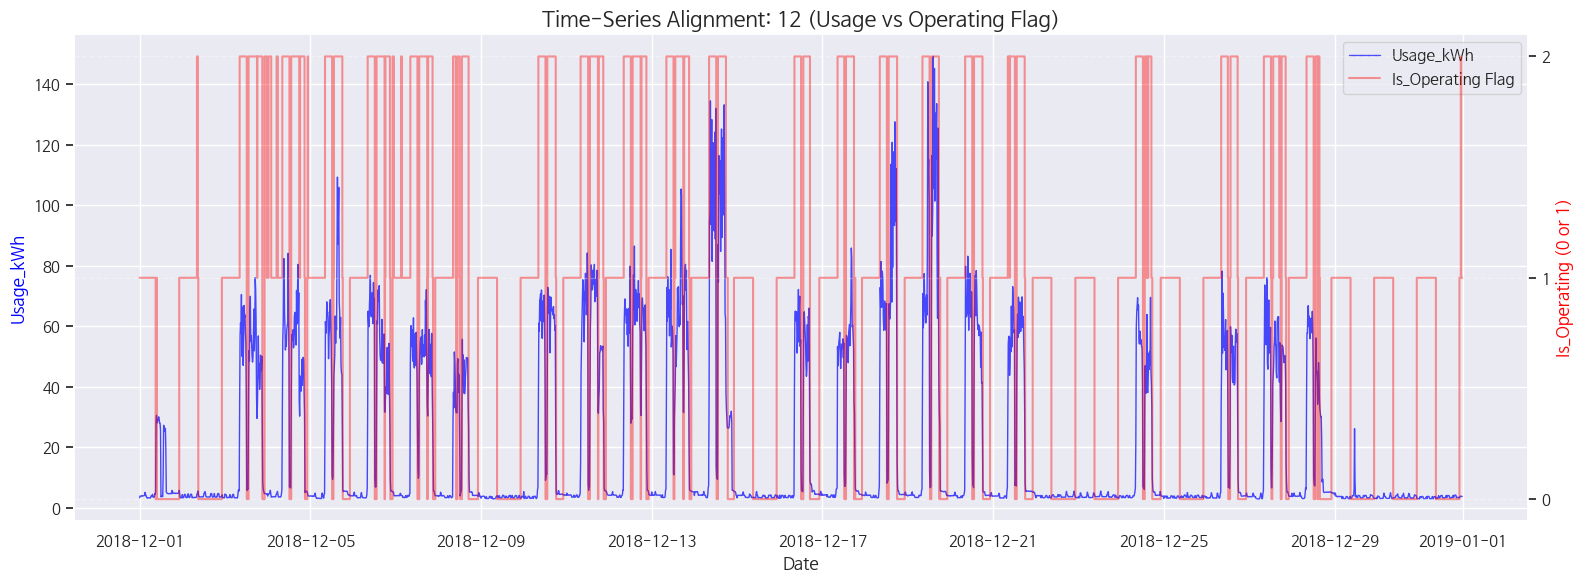

▶ 논리적 오류 1 (정지 상태이나 모터 가동됨): 620건
▶ 논리적 오류 2 (가동 상태이나 전력 사용량 극단적 낮음): 7574건

경고: Is_Operating 피처에 논리적 결함이 존재합니다. 산출 로직을 다시 확인하십시오.


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 분포 분리 검증 (KDE Plot)
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Usage_kWh', hue='Is_Operating_Flag', fill=True, common_norm=False, palette='Set1', alpha=0.5)
plt.title('Distribution of Usage_kWh by Is_Operating Status', fontsize=14)
plt.xlabel('Usage_kWh')
plt.ylabel('Density')
plt.show()

# 2. 시계열 정합성 검증

for month in [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12]:
    # 해당 월의 데이터 필터링
    sample_df = df[df['Month'] == month]
    
    fig, ax1 = plt.subplots(figsize=(16, 6))
    ax2 = ax1.twinx()

    # 전력 사용량 (Usage_kWh) - 선 그래프
    ax1.plot(sample_df['date'], sample_df['Usage_kWh'], color='blue', label='Usage_kWh', alpha=0.7, linewidth=1)
    
    # 가동 여부 플래그 (Is_Operating_Flag) - 계단식 그래프
    ax2.step(sample_df['date'], sample_df['Is_Operating_Flag'], color='red', label='Is_Operating Flag', alpha=0.4, where='post')

    # 축 설정
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Usage_kWh', color='blue', fontsize=12)
    ax2.set_ylabel('Is_Operating (0 or 1)', color='red', fontsize=12)
    ax2.set_yticks([0, 1, 2])
    
    plt.title(f'Time-Series Alignment: {month} (Usage vs Operating Flag)', fontsize=15)
    
    # 범례 통합 표시 (선택 사항)
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

    plt.grid(True, which='both', linestyle='--', alpha=0.3)
    plt.tight_layout()
    
    # 차트 저장 혹은 출력
    # plt.savefig(f'alignment_{month}.png') 
    plt.show()

# 3. 논리적 모순 데이터 검출 (Contradiction Check)
# 기준치(threshold)는 실제 공정의 기저 부하 수준에 맞춰 조정 필요
base_load_threshold = df['Usage_kWh'].quantile(0.05) + 2 # 예: 하위 5% 수준을 기저 부하로 가정

contradiction_1 = df[(df['Is_Operating_Flag'] == 0) & (df['Motor_Operating_Rate'] > 0.05)]
contradiction_2 = df[(df['Is_Operating_Flag'] == 1) & (df['Usage_kWh'] < base_load_threshold)]

print(f"▶ 논리적 오류 1 (정지 상태이나 모터 가동됨): {len(contradiction_1)}건")
print(f"▶ 논리적 오류 2 (가동 상태이나 전력 사용량 극단적 낮음): {len(contradiction_2)}건")

if len(contradiction_1) > 0 or len(contradiction_2) > 0:
    print("\n경고: Is_Operating 피처에 논리적 결함이 존재합니다. 산출 로직을 다시 확인하십시오.")

In [12]:
df.columns

Index(['date', 'Usage_kWh', 'Lagging_Current_Reactive_Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2_ppm',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type', 'Hour', 'DayOfWeek', 'Month',
       'Year', 'Is_Weekend', 'Season', 'Month_sin', 'Month_cos',
       'DayOfWeek_sin', 'DayOfWeek_cos', 'System_Stress_Load',
       'Reactive_Intensity', 'Apparent_Power', 'PF_Physical',
       'Motor_Moving_Avg_1h_std', 'Motor_Operating_Rate',
       'Capacitor_Operating_Rate', 'Q_total_abs', 'Motor_Ratio',
       'Capacitor_Ratio', 'Over_Correction_Flag', 'Is_Operating_Flag'],
      dtype='object')

<Axes: xlabel='WeekStatus', ylabel='Usage_kWh'>

Text(0.5, 1.0, 'Analysis: WeekStatus vs Usage_kWh')

Text(0.5, 0, 'WeekStatus')

Text(0, 0.5, 'Usage_kWh')

<Axes: xlabel='Day_of_week', ylabel='Usage_kWh'>

Text(0.5, 1.0, 'Analysis: Day_of_week vs Usage_kWh')

Text(0.5, 0, 'Day_of_week')

Text(0, 0.5, 'Usage_kWh')

<Axes: xlabel='Load_Type', ylabel='Usage_kWh'>

Text(0.5, 1.0, 'Analysis: Load_Type vs Usage_kWh')

Text(0.5, 0, 'Load_Type')

Text(0, 0.5, 'Usage_kWh')

<Axes: xlabel='Month', ylabel='Usage_kWh'>

Text(0.5, 1.0, 'Analysis: Month vs Usage_kWh')

Text(0.5, 0, 'Month')

Text(0, 0.5, 'Usage_kWh')

<Axes: xlabel='Hour', ylabel='Usage_kWh'>

Text(0.5, 1.0, 'Analysis: Hour vs Usage_kWh')

Text(0.5, 0, 'Hour')

Text(0, 0.5, 'Usage_kWh')

<Axes: xlabel='Season', ylabel='Usage_kWh'>

Text(0.5, 1.0, 'Analysis: Season vs Usage_kWh')

Text(0.5, 0, 'Season')

Text(0, 0.5, 'Usage_kWh')

<Axes: xlabel='Year', ylabel='Usage_kWh'>

Text(0.5, 1.0, 'Analysis: Year vs Usage_kWh')

Text(0.5, 0, 'Year')

Text(0, 0.5, 'Usage_kWh')

<Axes: xlabel='Is_Weekend', ylabel='Usage_kWh'>

Text(0.5, 1.0, 'Analysis: Is_Weekend vs Usage_kWh')

Text(0.5, 0, 'Is_Weekend')

Text(0, 0.5, 'Usage_kWh')

<Axes: xlabel='DayOfWeek', ylabel='Usage_kWh'>

Text(0.5, 1.0, 'Analysis: DayOfWeek vs Usage_kWh')

Text(0.5, 0, 'DayOfWeek')

Text(0, 0.5, 'Usage_kWh')

<Axes: xlabel='Lagging_Current_Reactive_Power_kVarh', ylabel='Usage_kWh'>

Text(0.5, 1.0, 'Analysis: Lagging_Current_Reactive_Power_kVarh vs Usage_kWh')

Text(0.5, 0, 'Lagging_Current_Reactive_Power_kVarh')

Text(0, 0.5, 'Usage_kWh')

<Axes: xlabel='Leading_Current_Reactive_Power_kVarh', ylabel='Usage_kWh'>

Text(0.5, 1.0, 'Analysis: Leading_Current_Reactive_Power_kVarh vs Usage_kWh')

Text(0.5, 0, 'Leading_Current_Reactive_Power_kVarh')

Text(0, 0.5, 'Usage_kWh')

<Axes: xlabel='CO2_ppm', ylabel='Usage_kWh'>

Text(0.5, 1.0, 'Analysis: CO2_ppm vs Usage_kWh')

Text(0.5, 0, 'CO2_ppm')

Text(0, 0.5, 'Usage_kWh')

<Axes: xlabel='Lagging_Current_Power_Factor', ylabel='Usage_kWh'>

Text(0.5, 1.0, 'Analysis: Lagging_Current_Power_Factor vs Usage_kWh')

Text(0.5, 0, 'Lagging_Current_Power_Factor')

Text(0, 0.5, 'Usage_kWh')

<Axes: xlabel='Leading_Current_Power_Factor', ylabel='Usage_kWh'>

Text(0.5, 1.0, 'Analysis: Leading_Current_Power_Factor vs Usage_kWh')

Text(0.5, 0, 'Leading_Current_Power_Factor')

Text(0, 0.5, 'Usage_kWh')

<Axes: xlabel='NSM', ylabel='Usage_kWh'>

Text(0.5, 1.0, 'Analysis: NSM vs Usage_kWh')

Text(0.5, 0, 'NSM')

Text(0, 0.5, 'Usage_kWh')

<Axes: xlabel='System_Stress_Load', ylabel='Usage_kWh'>

Text(0.5, 1.0, 'Analysis: System_Stress_Load vs Usage_kWh')

Text(0.5, 0, 'System_Stress_Load')

Text(0, 0.5, 'Usage_kWh')

<Axes: xlabel='Reactive_Intensity', ylabel='Usage_kWh'>

Text(0.5, 1.0, 'Analysis: Reactive_Intensity vs Usage_kWh')

Text(0.5, 0, 'Reactive_Intensity')

Text(0, 0.5, 'Usage_kWh')

<Axes: xlabel='Apparent_Power', ylabel='Usage_kWh'>

Text(0.5, 1.0, 'Analysis: Apparent_Power vs Usage_kWh')

Text(0.5, 0, 'Apparent_Power')

Text(0, 0.5, 'Usage_kWh')

<Axes: xlabel='PF_Physical', ylabel='Usage_kWh'>

Text(0.5, 1.0, 'Analysis: PF_Physical vs Usage_kWh')

Text(0.5, 0, 'PF_Physical')

Text(0, 0.5, 'Usage_kWh')

<Axes: xlabel='Motor_Moving_Avg_1h_std', ylabel='Usage_kWh'>

Text(0.5, 1.0, 'Analysis: Motor_Moving_Avg_1h_std vs Usage_kWh')

Text(0.5, 0, 'Motor_Moving_Avg_1h_std')

Text(0, 0.5, 'Usage_kWh')

<Axes: xlabel='Motor_Operating_Rate', ylabel='Usage_kWh'>

Text(0.5, 1.0, 'Analysis: Motor_Operating_Rate vs Usage_kWh')

Text(0.5, 0, 'Motor_Operating_Rate')

Text(0, 0.5, 'Usage_kWh')

<Axes: xlabel='Capacitor_Operating_Rate', ylabel='Usage_kWh'>

Text(0.5, 1.0, 'Analysis: Capacitor_Operating_Rate vs Usage_kWh')

Text(0.5, 0, 'Capacitor_Operating_Rate')

Text(0, 0.5, 'Usage_kWh')

<Axes: xlabel='Q_total_abs', ylabel='Usage_kWh'>

Text(0.5, 1.0, 'Analysis: Q_total_abs vs Usage_kWh')

Text(0.5, 0, 'Q_total_abs')

Text(0, 0.5, 'Usage_kWh')

<Axes: xlabel='Motor_Ratio', ylabel='Usage_kWh'>

Text(0.5, 1.0, 'Analysis: Motor_Ratio vs Usage_kWh')

Text(0.5, 0, 'Motor_Ratio')

Text(0, 0.5, 'Usage_kWh')

<Axes: xlabel='Capacitor_Ratio', ylabel='Usage_kWh'>

Text(0.5, 1.0, 'Analysis: Capacitor_Ratio vs Usage_kWh')

Text(0.5, 0, 'Capacitor_Ratio')

Text(0, 0.5, 'Usage_kWh')

<Axes: xlabel='Over_Correction_Flag', ylabel='Usage_kWh'>

Text(0.5, 1.0, 'Analysis: Over_Correction_Flag vs Usage_kWh')

Text(0.5, 0, 'Over_Correction_Flag')

Text(0, 0.5, 'Usage_kWh')

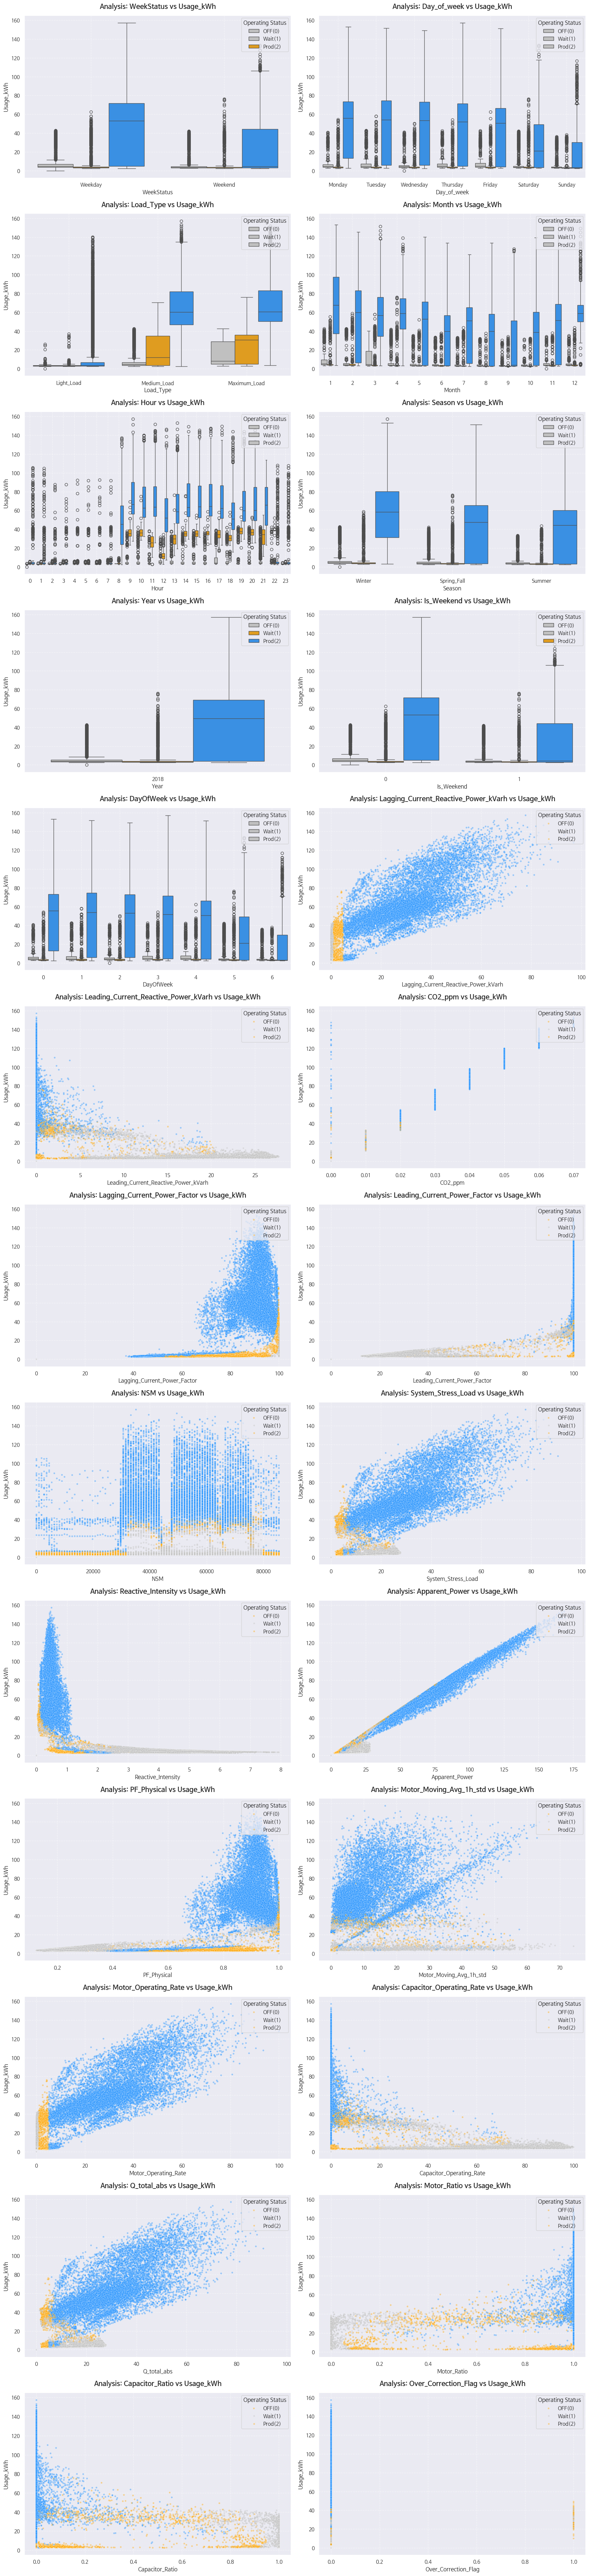

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 컬럼 분류 (제공해주신 Index 기준으로 현행화)
# 'Load_Level'과 'Process_Load_Factor'는 리스트에 없어 제외하고, 실제 있는 컬럼으로 대체했습니다.
cat_cols = ['WeekStatus', 'Day_of_week', 'Load_Type', 'Month', 'Hour', 'Season', 'Year', 'Is_Weekend', 'DayOfWeek'] 
num_cols = [
    'Lagging_Current_Reactive_Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 
    'CO2_ppm', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 
    'NSM', 'System_Stress_Load', 'Reactive_Intensity', 'Apparent_Power', 
    'PF_Physical', 'Motor_Moving_Avg_1h_std', 'Motor_Operating_Rate', 
    'Capacitor_Operating_Rate', 'Q_total_abs', 'Motor_Ratio', 'Capacitor_Ratio',
    'Over_Correction_Flag', 'Production_Capacity_Pct'
]

# 2. 변수 선언
target = 'Usage_kWh'
split_by = 'Is_Operating_Flag'  # 3단계 상태 변수명으로 수정
data_source = df

# target과 split_by, 그리고 시계열(date) 제외한 피처 리스트 생성
all_target_cols = [c for c in (cat_cols + num_cols) if c in df.columns and c not in [target, split_by, 'date']]

# 3. 실행 로직
nrows = (len(all_target_cols) + 1) // 2
fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(18, 6 * nrows))
axes = axes.flatten()

# 3단계 상태에 대한 명확한 컬러 맵 지정 (0:Grey, 1:Orange, 2:Blue)
custom_palette = {0: 'silver', 1: 'orange', 2: 'dodgerblue'}

for i, col in enumerate(all_target_cols):
    ax = axes[i]
    
    if col in cat_cols:
        # 범주형: Boxplot (상태별 분포 비교)
        sns.boxplot(data=data_source, x=col, y=target, hue=split_by, ax=ax, palette=custom_palette)
    else:
        # 수치형: Scatterplot (군집 및 상관관계 확인)
        sns.scatterplot(data=data_source, x=col, y=target, hue=split_by, ax=ax, alpha=0.4, palette=custom_palette, s=15)

    ax.set_title(f'Analysis: {col} vs {target}', fontsize=15, fontweight='bold', pad=15)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel(target, fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.5)

    if ax.get_legend() is not None:
        ax.legend(title='Operating Status', loc='upper right', labels=['OFF(0)', 'Wait(1)', 'Prod(2)'])

# 남는 빈 서브플롯 제거
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## <b> [Phase 2: 탐색적 데이터 분석(EDA) 및 인사이트 시각화]

<big><b>⚡ 역률(Power Factor) 개념 및 계산 기준 </big></b>

| 구분 | 계산식 | 목적 | 활용 포인트 |
|------|--------|------|--------------|
| 공정 기준 PF <br> (Physical PF) |  $\frac{P}{\sqrt{P^2 + Q^2}}$|  설비·공정 효율 판단 | 공정 비효율, 과부하, 무효전력 과다 식별 |
| 한전 기준 PF <br> (KEPCO PF) | $ \frac{P}{\sqrt{P^2 + (Q_{\rm Lag} + Q_{\rm Lead})^2}}$ |  전기요금 최적화 | 요금 패널티 최소화, 전력 비용 절감 전략 |

💡 포인트  
- **공정 PF** → 설비/공정 효율 지표  
- **한전 PF** → 요금 패널티 최소화 전략  
- 기준선 0.9 붉은 점선 → 역률 이상/미달 구간 직관적 확인  
- `NSM` 기준으로 그룹화 → 시간대별 평균 비교 가능


<table style="border-collapse: collapse; width: 100%; color: #e0e0e0; background-color: #1e1e1e; border: 1px solid #444;">
    <thead>
        <tr style="background-color: #333; color: #ffffff;">
            <th style="padding: 12px; border: 1px solid #444; text-align: left;">분석 계층</th>
            <th style="padding: 12px; border: 1px solid #444; text-align: left;">핵심 피처 (Features)</th>
            <th style="padding: 12px; border: 1px solid #444; text-align: left;">분석적 역할 및 도입 사유</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 10px; border: 1px solid #444; font-weight: bold; color: #81a1c1;">상태 &amp; Context</td>
            <td style="padding: 10px; border: 1px solid #444; font-family: 'Courier New', monospace; color: #a3be8c;">Is_Operating, Process_Load_Factor, Hour, DayOfWeek</td>
            <td style="padding: 10px; border: 1px solid #444;">조업 패턴 및 주기성 학습, CO2 기반 공정 부하 강도 정의</td>
        </tr>
        <tr>
            <td style="padding: 10px; border: 1px solid #444; font-weight: bold; color: #81a1c1;">제어 변수 (X)</td>
            <td style="padding: 10px; border: 1px solid #444; font-family: 'Courier New', monospace; color: #a3be8c;">Motor_Operating_Rate, Capacitor_Operating_Rate, Lagging/Leading kVarh</td>
            <td style="padding: 10px; border: 1px solid #444;">직접 제어 가능한 물리적 레버 및 설비별 실제 가동량 소스</td>
        </tr>
        <tr>
            <td style="padding: 10px; border: 1px solid #444; font-weight: bold; color: #81a1c1;">성과 &amp; 품질 (Y)</td>
            <td style="padding: 10px; border: 1px solid #444; font-family: 'Courier New', monospace; color: #a3be8c;">PF_Physical, System_Stress_Load, Reactive_Intensity, Usage_kWh</td>
            <td style="padding: 10px; border: 1px solid #444;">최적화 타겟(사용량), 설비 노후화 및 에너지 효율 판단 척도</td>
        </tr>
        <tr>
            <td style="padding: 10px; border: 1px solid #444; font-weight: bold; color: #81a1c1;">제약 조건</td>
            <td style="padding: 10px; border: 1px solid #444; font-family: 'Courier New', monospace; color: #a3be8c;">Over_Correction_Flag</td>
            <td style="padding: 10px; border: 1px solid #444;">시스템 안정성 및 고조파 리스크 방지를 위한 가이드라인</td>
        </tr>
    </tbody>
</table>

<table style="border-collapse: collapse; width: 100%; color: #2e3440; background-color: #ffffff; border: 1px solid #d8dee9; font-family: system-ui, -apple-system, sans-serif;">
    <thead>
        <tr style="background-color: #eceff4; color: #2e3440; border-bottom: 2px solid #d8dee9;">
            <th style="padding: 12px; border: 1px solid #d8dee9; text-align: left;">대응 시나리오</th>
            <th style="padding: 12px; border: 1px solid #d8dee9; text-align: left;">도입 피처/로직</th>
            <th style="padding: 12px; border: 1px solid #d8dee9; text-align: left;">비판적 설계 목적</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="padding: 10px; border: 1px solid #d8dee9; font-weight: bold; color: #5e81ac; background-color: #f8f9fb;">규칙 전환 (선택3→2)</td>
            <td style="padding: 10px; border: 1px solid #d8dee9; font-family: 'Courier New', monospace; color: #4c566a;">Saving_Opportunity_Score</td>
            <td style="padding: 10px; border: 1px solid #d8dee9;">요금제 종류에 상관없이 '최대 비용 대비 절감량'으로 보상을 표준화하여 모델 혼란 방지</td>
        </tr>
        <tr>
            <td style="padding: 10px; border: 1px solid #d8dee9; font-weight: bold; color: #5e81ac; background-color: #f8f9fb;">2026 정책 가변성</td>
            <td style="padding: 10px; border: 1px solid #d8dee9; font-family: 'Courier New', monospace; color: #4c566a;">Dynamic_Policy_Threshold</td>
            <td style="padding: 10px; border: 1px solid #d8dee9;">역률 기준(0.9~0.95), 탄소 가중치 등을 외부 인자로 받아 시뮬레이션 가능하도록 설계</td>
        </tr>
        <tr>
            <td style="padding: 10px; border: 1px solid #d8dee9; font-weight: bold; color: #bf616a; background-color: #fffafb;">미래 리스크</td>
            <td style="padding: 10px; border: 1px solid #d8dee9; font-family: 'Courier New', monospace; color: #4c566a;">Surcharge_Expansion_Beta</td>
            <td style="padding: 10px; border: 1px solid #d8dee9;">연료비 조정액 등 사후에 추가될 수 있는 비용 항목을 위한 확장 슬롯(Placeholder) 확보</td>
        </tr>
    </tbody>
</table>

In [14]:
# 학습에 사용할 '오염되지 않은' 피처 리스트
features = [
    'Hour', 
    'Is_Weekend', 
    'Month_sin', 
    'Month_cos', 
    'DayOfWeek_sin', 
    'DayOfWeek_cos', 
    'Motor_Operating_Rate',         # 핵심 제어 변수 1
    'Capacitor_Operating_Rate',     # 핵심 제어 변수 2
    'Is_Operating_Flag',            # (수정됨) 모터 가동률 기반 플래그
    'Motor_Moving_Avg_1h_std'       # (수정됨) 모터 가동 변동성
]

# 타겟 변수
target_usage = 'Usage_kWh'
target_pf = 'PF_Physical'

<Figure size 1000x800 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Correlation Heatmap: Process Variables & Energy Usage')

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5]),
 [Text(0.5, 0, 'Usage_kWh'),
  Text(1.5, 0, 'Hour'),
  Text(2.5, 0, 'Month'),
  Text(3.5, 0, 'DayOfWeek'),
  Text(4.5, 0, 'System_Stress_Load'),
  Text(5.5, 0, 'PF_Physical'),
  Text(6.5, 0, 'Motor_Moving_Avg_1h_std'),
  Text(7.5, 0, 'Motor_Operating_Rate'),
  Text(8.5, 0, 'Capacitor_Operating_Rate'),
  Text(9.5, 0, 'Is_Operating_Flag')])

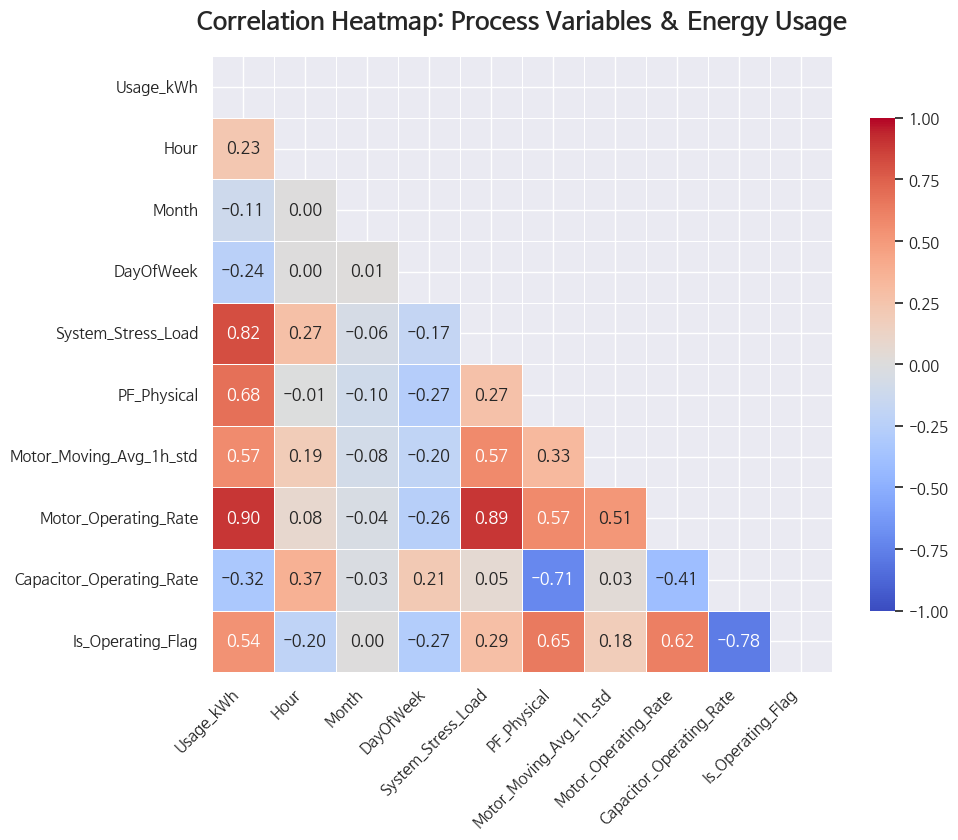

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. 분석 대상 수치형 컬럼 선택
# 'Production_Capacity_Pct'는 중복 정보이므로 제외하거나, 확인용으로만 포함하십시오.
# 'Is_Operating_Flag'는 수치(0, 1, 2)이므로 상관계수 계산에 포함하는 것이 좋습니다.
corr_cols = [
    'Usage_kWh', 
    'Hour', 'Month', 'DayOfWeek', 'System_Stress_Load', 
    'PF_Physical', 'Motor_Moving_Avg_1h_std', 'Motor_Operating_Rate', 
    'Capacitor_Operating_Rate',  
    'Is_Operating_Flag'
]

# 데이터프레임에서 존재하는 컬럼만 필터링
target_df = df[corr_cols].dropna()

# 2. 상관계수 행렬 계산
corr_matrix = target_df.corr()

# 3. 히트맵 시각화
plt.figure(figsize=(10, 8))

# 마스크 설정 (상단 삼각형 제거하여 가독성 향상)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, 
            annot=True,              # 수치 표시
            fmt=".2f",               # 소수점 둘째 자리까지
            mask=mask,               # 마스크 적용
            cmap='coolwarm',         # 색상 맵 (양수-Red, 음수-Blue)
            vmin=-1, vmax=1,         # 범위 고정
            center=0,
            linewidths=.5,
            cbar_kws={"shrink": .8})

plt.title('Correlation Heatmap: Process Variables & Energy Usage', fontsize=18, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.show()

In [16]:
# 학습에 사용할 '오염되지 않은' 피처 리스트
features = [
    'Hour', 
    'Is_Weekend', 
    'Month_sin', 
    'Month_cos', 
    'DayOfWeek_sin', 
    'DayOfWeek_cos', 
    'Motor_Operating_Rate',         # 핵심 제어 변수 1
    'Capacitor_Operating_Rate',     # 핵심 제어 변수 2
    'Is_Operating_Flag',            # (수정됨) 모터 가동률 기반 플래그
    'Motor_Moving_Avg_1h_std'       # (수정됨) 모터 가동 변동성
]

# 타겟 변수
target_usage = 'Usage_kWh'
target_pf = 'PF_Physical'

In [17]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# 2. 데이터 타입 업데이트 (객체 참조 1회 사용)
target_df = df.copy() # 혹은 학습용 원본 df

# 범주형 컬럼을 category 타입으로 변환 (XGBoost 학습 최적화)
cat_features = ['Hour', 'Is_Weekend', 'Is_Operating_Flag']
for col in cat_features:
    target_df[col] = target_df[col].astype('category')

print("학습용 피처 선정이 완료되었습니다. 범주형 데이터가 'category' 타입으로 업데이트되었습니다.")

# 2. 시계열 분할 (2017년 데이터 기준 상위 80% 학습, 하위 20% 검증)
split_idx = int(len(target_df) * 0.8)
train_df = target_df.iloc[:split_idx]
test_df = target_df.iloc[split_idx:]

X_train, y_train_usage = train_df[features], train_df[target_usage]
X_test, y_test_usage = test_df[features], test_df[target_usage]

y_train_pf = train_df[target_pf]
y_test_pf = test_df[target_pf]
# 3. 모델 정의 및 학습 (기본 파라미터 설정)
# 1. 전력 사용량(Usage) 예측 모델
model_usage = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    enable_categorical=True,
    early_stopping_rounds=50
)
model_usage.fit(X_train, y_train_usage, eval_set=[(X_test, y_test_usage)], verbose=False)

# 2. 역률(PF) 예측 모델
model_pf = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    enable_categorical=True,
    early_stopping_rounds=50
)
model_pf.fit(X_train, y_train_pf, eval_set=[(X_test, y_test_pf)], verbose=False)

# 4. 성능 평가
preds = model_usage.predict(X_test)
print(f"MAE: {mean_absolute_error(y_test_usage, preds):.4f}")
print(f"R2 Score: {r2_score(y_test_usage, preds):.4f}")

# 4. 성능 평가
preds_PF = model_pf.predict(X_test)
print(f"MAE: {mean_absolute_error(y_test_pf, preds_PF):.4f}")
print(f"R2 Score: {r2_score(y_test_pf, preds_PF):.4f}")

학습용 피처 선정이 완료되었습니다. 범주형 데이터가 'category' 타입으로 업데이트되었습니다.


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,50
,enable_categorical,True
,eval_metric,None


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,50
,enable_categorical,True
,eval_metric,None


MAE: 4.1255
R2 Score: 0.9516
MAE: 0.0499
R2 Score: 0.9265



=== Feature Importance Top 5 ===
Motor_Operating_Rate        0.420874
Is_Operating_Flag           0.385634
Motor_Moving_Avg_1h_std     0.087796
Capacitor_Operating_Rate    0.032934
Hour                        0.032370
dtype: float32


<Figure size 1200x600 with 0 Axes>

Text(0.5, 1.0, 'Feature Importances (Corrected)')

<Axes: title={'center': 'Feature Importances (Corrected)'}, ylabel='None'>

Text(0.5, 0, 'Relative Importance')

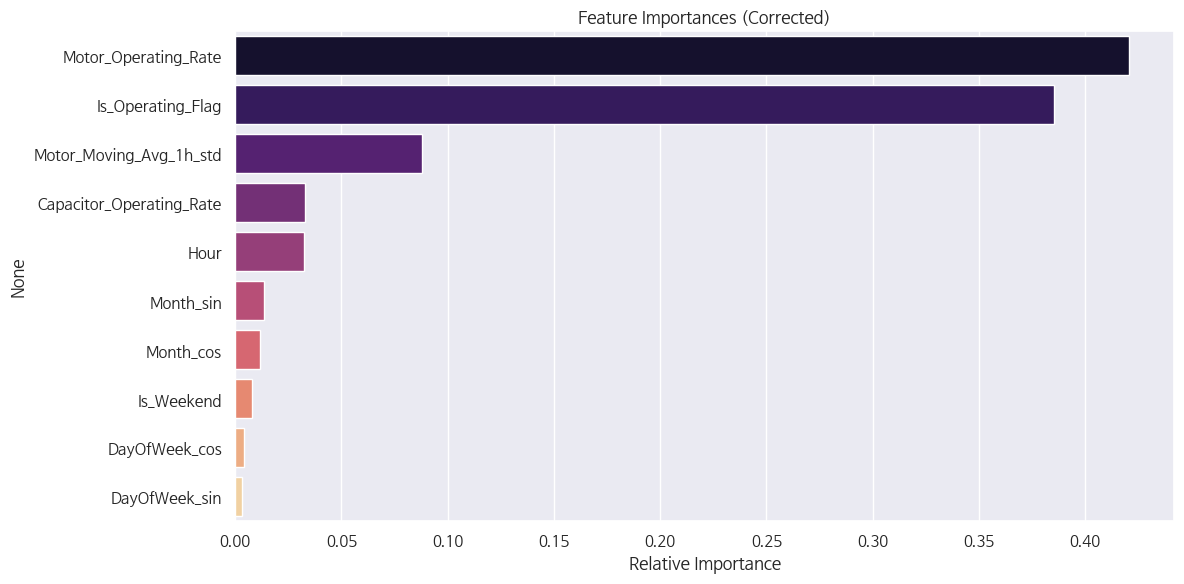

In [18]:
# 피처 중요도 확인 (텍스트 출력)
importances = pd.Series(model_usage.feature_importances_, index=features).sort_values(ascending=False)

print("\n=== Feature Importance Top 5 ===")
print(importances.head(5))

# 1. 정렬된 데이터를 변수에 저장
top_features = importances.sort_values(ascending=False).head(10)

# 2. 그래프 그리기
plt.figure(figsize=(12, 6))
plt.title("Feature Importances (Corrected)")

# x에는 중요도 수치(values), y에는 피처 이름(index)을 직접 전달
sns.barplot(x=top_features.values, y=top_features.index, palette='magma')

plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()


=== Feature Importance Top 5 ===
Capacitor_Operating_Rate    0.486388
Motor_Moving_Avg_1h_std     0.176820
Motor_Operating_Rate        0.100896
Hour                        0.076051
Month_sin                   0.063111
dtype: float32


<Figure size 1200x600 with 0 Axes>

Text(0.5, 1.0, 'Feature Importances (Corrected)')

<Axes: title={'center': 'Feature Importances (Corrected)'}, ylabel='None'>

Text(0.5, 0, 'Relative Importance')

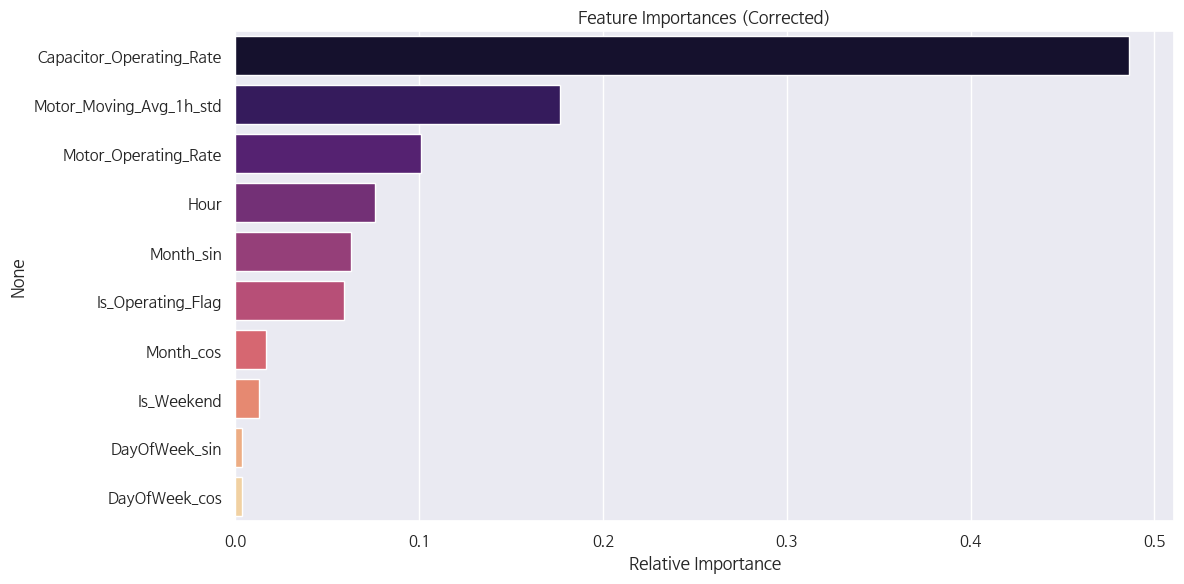

In [19]:
# 피처 중요도 확인 (텍스트 출력)
importances = pd.Series(model_pf.feature_importances_, index=features).sort_values(ascending=False)

print("\n=== Feature Importance Top 5 ===")
print(importances.head(5))

# 1. 정렬된 데이터를 변수에 저장
top_features = importances.sort_values(ascending=False).head(10)

# 2. 그래프 그리기
plt.figure(figsize=(12, 6))
plt.title("Feature Importances (Corrected)")

# x에는 중요도 수치(values), y에는 피처 이름(index)을 직접 전달
sns.barplot(x=top_features.values, y=top_features.index, palette='magma')

plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()

In [20]:
import pandas as pd
import numpy as np
import json

def calculate_elec_cost_scenario(
    df: pd.DataFrame,
    config_path: str,
    scenario_name: str,  # 핵심: 여기서 시나리오 이름을 선택
    contract_kw: float = None
) -> pd.DataFrame:

    # 1. 마스터 설정 파일 로드
    with open(config_path, 'r', encoding='utf-8') as f:
        master_config = json.load(f)

    # 2. 특정 시나리오 데이터 추출
    if scenario_name not in master_config['scenarios']:
        raise ValueError(f"시나리오 '{scenario_name}'을(를) 찾을 수 없습니다. 가능한 시나리오: {list(master_config['scenarios'].keys())}")

    config = master_config['scenarios'][scenario_name]
    print(f"▶ 선택된 시나리오: {scenario_name} ({config.get('desc', '')})")

    if contract_kw is None:
        if 'contract_kw' in config:
            contract_kw = config['contract_kw']
            print(f"   └ 계약전력: {contract_kw}kW (시나리오 설정값 적용)")
        else:
            # 안전장치: JSON에도 없고 인자도 없으면 에러
            raise ValueError("contract_kw가 함수 인자로도, JSON 설정으로도 제공되지 않았습니다.")
    else:
        print(f"   └ 계약전력: {contract_kw}kW (사용자 입력값 우선 적용)")

    df = df.copy()

    # --- 이하 로직은 설정값(config)을 사용하여 자동 계산 ---

    # 3. 시간대(TOU) 적용 (config['tou_schedule'] 사용)
    df['tou'] = 'mid' # 기본값

    tou_sched = config['tou_schedule']

    # 제주도 등 특수 케이스 처리를 위한 계절 키 확인
    # (설정에 없는 계절은 무시하거나 에러 처리 가능)
    available_seasons = [s for s in ['summer', 'winter', 'spring_fall'] if s in tou_sched]

    for season in available_seasons:
        season_mask = (df['Season'] == season)
        schedule = tou_sched[season]

        for tou_type, ranges in schedule.items():
            for start, end in ranges:
                # 22시~08시 같은 자정 넘김 처리 (OR 조건)
                if start < end:
                    time_mask = (df['Hour'] >= start) & (df['Hour'] < end)
                else:
                    time_mask = (df['Hour'] >= start) | (df['Hour'] < end)

                df.loc[season_mask & time_mask, 'tou'] = tou_type

    # 4. 토요일/공휴일 특례 (2018/2026 공통 룰 적용)
    # 필요시 이 룰도 config에서 on/off 할 수 있게 확장 가능
    day_of_week = df['date'].dt.dayofweek
    
    # 1) 토요일(5) 특례: 최대부하 -> 중간부하
    sat_mask = (day_of_week == 5) & (df['tou'] == 'peak')
    df.loc[sat_mask, 'tou'] = 'mid'
    
    # 2) 일요일(6) 특례: 24시간 내내 -> 경부하
    sun_mask = (day_of_week == 6)
    df.loc[sun_mask, 'tou'] = 'off'

    # --- 5. 역률 계산 및 가감률 도출 (JSON 기반) ---
    pf_cfg = config.get('pf_logic')

    # JSON에서 시간 설정 가져오기 (없으면 기본값 9, 23 적용)
    lag_start = pf_cfg.get('lag_start', 9) # 기본값 9시
    lag_end = pf_cfg.get('lag_end', 23)    # 기본값 23시

    # 이미지에 명시된 08시~22시 적용
    df['is_lag_period'] = np.where((df['Hour'] >= lag_start) & (df['Hour'] < lag_end), 1, 0)
    
    # 월별/구간별(지상, 진상) 유효/무효 전력 합계
    grouped = df.groupby(['Month', 'is_lag_period']).agg({
        'Usage_kWh': 'sum',
        'Lagging_Current_Reactive_Power_kVarh': 'sum',
        'Leading_Current_Reactive_Power_kVarh': 'sum'
    }).reset_index()
    
    # 1. 무효전력량(kVARh) 컬럼 선택
    # 조건 목록: 지상 구간일 때와 아닐 때(진상)
    pf_conditions = [
        (grouped['is_lag_period'] == 1),  # 지상(Lagging)
        (grouped['is_lag_period'] == 0)   # 진상(Leading)
    ]
    
    # 결과 목록: 각각 사용할 컬럼명
    pf_choices = [
        grouped['Lagging_Current_Reactive_Power_kVarh'],
        grouped['Leading_Current_Reactive_Power_kVarh']
    ]
    
    # np.select로 구간별 kvarh 결정
    kvarh_vec = np.select(pf_conditions, pf_choices, default=0)
    
    # 2. 역률(PF) 값 계산
    with np.errstate(divide='ignore', invalid='ignore'):
        pf_vec = (grouped['Usage_kWh'] / np.sqrt(grouped['Usage_kWh']**2 + kvarh_vec**2)) * 100
        grouped['pf_val'] = np.where(grouped['Usage_kWh'] == 0, 100.0, np.minimum(100.0, pf_vec))
    
    # 3. 역률 가감률(pf_adj) 산정 (이미지 약관 기준 반영)
    rate = pf_cfg['rate_per_1_pct']
    max_adj = pf_cfg['max_adjustment']
    
    
    
    # 조건 목록 정의 (지상/진상 및 기준치 초과/미달)
    adj_conditions = [
        (grouped['is_lag_period'] == 1),  # 지상: 92% 기준 (할인/할증 모두 포함)
        (grouped['is_lag_period'] == 0)   # 진상: 95% 기준 (할증만 적용)
    ]
    
    # 결과 목록 정의
    adj_choices = [
        # 지상: (92 - 현재역률) * 0.002 -> ±10% 클립
        np.clip((pf_cfg['lag_target'] - grouped['pf_val']) * rate, -max_adj, max_adj),
    
        # 진상: 95% 미달 시만 할증 -> 0 ~ 10% 클립
        np.clip((pf_cfg['lead_target'] - grouped['pf_val']) * rate, 0, max_adj)
    ]
    
    grouped['pf_adj'] = np.select(adj_conditions, adj_choices, default=0.0)
    
    # 월별 최종 가감률 매핑
    monthly_adj = grouped.groupby('Month')['pf_adj'].sum().reset_index()
    df = df.merge(monthly_adj.rename(columns={'pf_adj': 'total_pf_adj'}), on='Month', how='left')
    
    # --- 6. 기본요금 산출 및 안분 ---
    # 피크 반영 기본요금 로직 (Billing Demand)
    monthly_peak = df.groupby('Month')['Usage_kWh'].transform('max') * 4
    df['billing_demand'] = np.maximum(monthly_peak, contract_kw * 0.3)
    
    # PF 가감이 반영된 월 총액
    df['monthly_basic_total'] = (df['billing_demand'] * config['base_rate']) * (1 + df['total_pf_adj'])
    
    # 시각화용 15분 안분
    month_total_usage = df.groupby('Month')['Usage_kWh'].transform('sum')
    df['allocated_base'] = np.where(month_total_usage > 0,
                                    df['monthly_basic_total'] * (df['Usage_kWh'] / month_total_usage), 0)
    
    # 5. 요금 계산 (Vectorized)
    price_map = config['unit_prices']
    
    # 단가 매핑 함수
    def get_price(row):
        # 해당 시나리오에 정의된 계절/시간대 단가 가져오기
        try:
            return price_map[row['season']][row['tou']]
        except KeyError:
            return 0.0 # 예외 처리
    
    df['unit_price'] = df.apply(get_price, axis=1)
    df['energy_cost'] = df['Usage_kWh'] * df['unit_price']
    
    
    # --- 7. 부가 요금 및 법정 제비용 (JSON 기반) ---
    fees_cfg = config.get('additional_fees', {})
    
    df['env_cost'] = df['Usage_kWh'] * fees_cfg.get('climate', 0)
    df['fuel_cost'] = df['Usage_kWh'] * fees_cfg.get('fuel', 0)
    
    
    # 공급가액 합계
    df['supply_price'] = df['energy_cost'] + df['env_cost'] + df['fuel_cost'] + df['allocated_base']
    
    # 전력기금 및 부가세 (JSON의 요율 적용)
    fund_rate = fees_cfg.get('fund_rate', 0.032)
    vat_rate = fees_cfg.get('vat_rate', 0.1)
    
    df['fund_cost'] = (df['supply_price'] * fund_rate).apply(np.floor)
    df['vat_cost'] = (df['supply_price'] * vat_rate).apply(lambda x: round(x, 0))
    
    df['total_cost'] = df['supply_price'] + df['fund_cost'] + df['vat_cost']
    
    return df

In [21]:
df['Motor_Operating_Rate'].describe()

count    35040.000000
mean        13.451020
std         16.825921
min          0.000000
25%          2.373336
50%          5.159426
75%         23.361882
max        100.000000
Name: Motor_Operating_Rate, dtype: float64

``` python
features = [
    'Hour', 
    'Is_Weekend', 
    'Month_sin', 
    'Month_cos', 
    'DayOfWeek_sin', 
    'DayOfWeek_cos', 
    'Motor_Operating_Rate',         # 핵심 제어 변수 1
    'Capacitor_Operating_Rate',     # 핵심 제어 변수 2
    'Is_Operating_Flag',            # (수정됨) 모터 가동률 기반 플래그
    'Motor_Moving_Avg_1h_std'       # (수정됨) 모터 가동 변동성
]


In [22]:
import numpy as np
import pandas as pd
import time
import json
import optuna
from tqdm.auto import tqdm  # 진행률 바 생성을 위한 라이브러리 추가

# Optuna 로그 숨기기 (루프 내에서 너무 많은 출력이 발생하는 것 방지)
optuna.logging.set_verbosity(optuna.logging.WARNING)

class HybridFastSimulator:
    def __init__(self, model_usage, model_pf, features, json_config_path):
        self.model_usage = model_usage
        self.model_pf = model_pf
        self.features = features
        
        # 요금제 JSON 로드
        with open(json_config_path, 'r', encoding='utf-8') as f:
            self.config = json.load(f)
            
    def _get_tou_price(self, scenario, month, hour):
        """계절 및 시간대별 전력 단가와 TOU 타입(off, mid, peak) 반환"""
        # 계절 판별 (기존 로직과 동일하게 유지)
        if month in [6, 7, 8]: season = 'summer'
        elif month in [11, 12, 1, 2]: season = 'winter'
        else: season = 'spring_fall'
            
        schedule = scenario['tou_schedule'][season]
        prices = scenario['unit_prices'][season]
        
        for tou_type, time_ranges in schedule.items():
            for start, end in time_ranges:
                # 야간 시간대(예: 22~8)가 자정을 넘기는 경우 처리
                if start > end:
                    if hour >= start or hour < end:
                        return prices[tou_type], tou_type
                else:
                    if start <= hour < end:
                        return prices[tou_type], tou_type
        return prices['off'], 'off' # 기본값

    def precompute_grid(self, df):
        """1단계: 전체 시간에 대한 그리드 배치 추론 (연산 속도의 핵심)"""
        print("⏳ 1단계: 대리 모델(XGBoost) 기반 35,040시간 가동률 그리드 사전 연산 중...")
        start_time = time.time()
        
        # 그리드 해상도: 모터 5% 단위 (21개), 콘덴서 10% 단위 (11개) -> 총 231개 조합
        self.motor_rates = np.linspace(0, 100, 101)
        self.cap_rates = np.linspace(0, 100, 11)
        M_grid, C_grid = np.meshgrid(self.motor_rates, self.cap_rates, indexing='ij')
        self.M_flat = M_grid.flatten()
        self.C_flat = C_grid.flatten()
        
        num_combinations = len(self.M_flat)
        N = len(df)
        
        self.usage_matrix = np.zeros((N, num_combinations))
        self.pf_matrix = np.zeros((N, num_combinations))
        
        X_base = df[self.features].values
        m_idx = self.features.index('Motor_Operating_Rate')
        c_idx = self.features.index('Capacitor_Operating_Rate')
        
        # tqdm 적용: 사전 연산 조합 진행률 표시
        for i in tqdm(range(num_combinations), desc="Grid Precomputing", unit="comb"):
            X_temp = X_base.copy()
            X_temp[:, m_idx] = self.M_flat[i]
            X_temp[:, c_idx] = self.C_flat[i]
            
            # 예측 수행
            self.usage_matrix[:, i] = self.model_usage.predict(X_temp)
            self.pf_matrix[:, i] = self.model_pf.predict(X_temp)
            
        print(f"✅ 사전 연산 완료! (소요 시간: {time.time() - start_time:.2f}초)")

    def fine_tune_optuna(self, X_row, m_idx, c_idx, base_m, base_c, current_price, target_prod, deficit):
        """2단계: 그리드에서 찾은 최적점 주변을 베이지안으로 미세 조정"""
        def objective(trial):
            # 그리드 최적점 주변 ±2.5% 범위 내에서 정밀 탐색
            m_rate = trial.suggest_float('m_rate', max(target_prod, base_m - 2.5), min(100.0, base_m + 2.5))
            c_rate = trial.suggest_float('c_rate', max(0.0, base_c - 5.0), min(100.0, base_c + 5.0))
            
            X_temp = X_row.copy()
            X_temp[m_idx] = m_rate
            X_temp[c_idx] = c_rate
            
            # 단일 행 예측 시 2D 배열 형태로 변환 필요
            usage = self.model_usage.predict(X_temp.reshape(1, -1))[0]
            pf = self.model_pf.predict(X_temp.reshape(1, -1))[0]
            
            cost = usage * current_price
            if pf < 0.90: cost += cost * 0.05 # 역률 페널티
            
            return cost
            
        study = optuna.create_study(direction="minimize")
        study.optimize(objective, n_trials=5) # 5번만 빠르게 탐색
        
        return study.best_params['m_rate'], study.best_params['c_rate']

    def run_scenario(self, df, scenario_key, labor_premium=50.0):
        """전체 시뮬레이션 루프 실행"""
        print(f"\n🚀 시뮬레이션 시작: {scenario_key} (야간 인건비 할증: {labor_premium}원/kWh)")
        scenario = self.config['scenarios'][scenario_key]

        # JSON에서 해당 시나리오의 역률 설정값 동적 로드 (없을 경우 과거 KEPCO 기본값 사용)
        pf_logic = scenario.get('pf_logic', {})
        lag_target = pf_logic.get('lag_target', 90) / 100.0   # 예: 0.92
        lead_target = pf_logic.get('lead_target', 95) / 100.0 # 예: 0.95
        lag_start = pf_logic.get('lag_start', 9)              # 예: 8
        lag_end = pf_logic.get('lag_end', 23)                 # 예: 22
        
        results = []
        current_deficit = 0.0

        m_idx = self.features.index('Motor_Operating_Rate')
        c_idx = self.features.index('Capacitor_Operating_Rate')
        X_base = df[self.features].values

        # tqdm 적용: 35,040시간 시뮬레이션 진행률 표시
        for t in tqdm(range(len(df)), desc=f"Simulating {scenario_key}", unit="step"):
            row = df.iloc[t]
            current_price, tou_type = self._get_tou_price(scenario, row['Month'], row['Hour'])
            
            # 1. 비용 행렬 계산 (Vectorized)
            is_night = (tou_type == 'off')
            effective_price = current_price + (labor_premium if is_night else 0.0)
                
            # --- (수정 전) 기존 로직 ---
            # cost_matrix = self.usage_matrix[t] * effective_price
            # pf_penalty_mask = self.pf_matrix[t] < 0.90
            # cost_matrix += np.where(pf_penalty_mask, self.usage_matrix[t] * current_price * 0.05, 0)
            
            # ==========================================================
            # 🚀 --- (수정 후) 한전 기준 엄격한 역률 방어 로직 ---
            # ==========================================================
            cost_matrix = self.usage_matrix[t] * effective_price
            
            # --- (추가할 부분) 시간 변수 추출 ---
            current_hour = row['Hour'] if 'hour' in row else row['Hour']
            
            # 지상(Lagging) 시간대 판별 로직
            is_lag_period = (lag_start <= current_hour < lag_end)
                
            
            # ==========================================================
            # 🚀 한전 기준 역률 페널티 동적 적용 (JSON 연동)
            # ==========================================================

            target_pf = lag_target if is_lag_period else lead_target
            pf_penalty_mask = self.pf_matrix[t] < target_pf

            # 페널티 금액 정의 (에러 방지를 위해 루프 내 상단 고정)
            penalty_amount = 999999.0
            
            # 조건 미달 시 강력한 페널티 (Hard Constraint)
            cost_matrix += np.where(pf_penalty_mask, penalty_amount, 0)
                
            # 지상역률 보상 (타겟 ~ 95% 구간 할인)
            if is_lag_period:
                pf_reward_mask = (self.pf_matrix[t] >= lag_target) & (self.pf_matrix[t] <= 0.95)
                cost_matrix -= np.where(pf_reward_mask, self.usage_matrix[t] * current_price * 0.05, 0)
    
            # 조건을 만족하는 조합이 '단 하나도 없을' 경우의 안전장치
            if np.all(pf_penalty_mask):
                cost_matrix += (target_pf - self.pf_matrix[t]) * 10000.0 
            else:
                cost_matrix += np.where(pf_penalty_mask, penalty_amount, 0)
     
            # 2. 물리적 생산 제약 (부채 + 목표량)
            # 기본 조업량의 95% 이상은 무조건 달성하도록 하한선 설정
            target_production = row['Motor_Operating_Rate'] * 0.95 
            if current_deficit > 0:
                target_production = min(100.0, target_production + current_deficit)
                
            valid_mask = self.M_flat >= target_production
            cost_matrix = np.where(valid_mask, cost_matrix, np.inf)
            
            # 3. 1차 그리드 서치 최적점 도출
            best_idx = np.argmin(cost_matrix)
            grid_m = self.M_flat[best_idx]
            grid_c = self.C_flat[best_idx]
            
            # 4. 2차 미세 조정 (선택적)
            # 피크 시간대이거나 요금이 비싼 시간대(mid, peak)에만 Optuna 미세 조정 가동
            if tou_type in ['peak', 'mid']:
                final_m, final_c = self.fine_tune_optuna(
                    X_base[t], m_idx, c_idx, grid_m, grid_c, current_price, target_production, current_deficit
                )
                # 미세조정된 값으로 최종 예측
                X_temp = X_base[t].copy()
                X_temp[m_idx] = final_m
                X_temp[c_idx] = final_c
                final_usage = self.model_usage.predict(X_temp.reshape(1, -1))[0]
                final_pf = self.model_pf.predict(X_temp.reshape(1, -1))[0]
            else:
                final_m, final_c = grid_m, grid_c
                final_usage = self.usage_matrix[t][best_idx]
                final_pf = self.pf_matrix[t][best_idx]
    
            # 5. 상태 업데이트
            actual_production_gap = row['Motor_Operating_Rate'] - final_m
            current_deficit = max(0.0, current_deficit + actual_production_gap)
            
            # 결과 기록
            new_row = row.copy()
            new_row['AI_Motor_Rate'] = final_m
            new_row['AI_Cap_Rate'] = final_c
            new_row['AI_Usage_kWh'] = final_usage
            new_row['AI_PF'] = final_pf
            new_row['Deficit_Status'] = current_deficit
            results.append(new_row)
            
        return pd.DataFrame(results)



In [23]:
# ----------------- [실행 방법] -----------------
# 1. 인스턴스 생성 및 사전 연산 (전체 피처 리스트 전달 필요)
simulator = HybridFastSimulator(model_usage, model_pf, features, 'electricity_config_master.json')
simulator.precompute_grid(df)

# 2. 시나리오별 실행
result_opt1 = simulator.run_scenario(df, '2018_industrial_HV_A_opt1', labor_premium=50.0)
result_opt2 = simulator.run_scenario(df, '2018_industrial_HV_A_opt2', labor_premium=50.0)
result_opt3 = simulator.run_scenario(df, '2018_industrial_HV_A_opt3', labor_premium=50.0)

⏳ 1단계: 대리 모델(XGBoost) 기반 35,040시간 가동률 그리드 사전 연산 중...


Grid Precomputing:   0%|          | 0/1111 [00:00<?, ?comb/s]

✅ 사전 연산 완료! (소요 시간: 75.35초)

🚀 시뮬레이션 시작: 2018_industrial_HV_A_opt1 (야간 인건비 할증: 50.0원/kWh)


Simulating 2018_industrial_HV_A_opt1:   0%|          | 0/35040 [00:00<?, ?step/s]


🚀 시뮬레이션 시작: 2018_industrial_HV_A_opt2 (야간 인건비 할증: 50.0원/kWh)


Simulating 2018_industrial_HV_A_opt2:   0%|          | 0/35040 [00:00<?, ?step/s]


🚀 시뮬레이션 시작: 2018_industrial_HV_A_opt3 (야간 인건비 할증: 50.0원/kWh)


Simulating 2018_industrial_HV_A_opt3:   0%|          | 0/35040 [00:00<?, ?step/s]

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_advanced_kpi_profile(df_original, df_ai, tou_off_start=22, tou_off_end=8):
    """
    [Advanced KPI 시각화 - 고대비(High Contrast) 버전]
    경부하 구간의 음영을 짙게 처리하고, 최대 피크 선을 강렬하게 부각합니다.
    """
    time_col = 'hour' if 'hour' in df_original.columns else 'Hour'
    orig_col = 'Usage_kWh'
    ai_col = 'AI_Usage_kWh'
    
    # 평균 및 최대치 산출
    mean_orig = df_original.groupby(time_col)[orig_col].mean()
    mean_opt = df_ai.groupby(time_col)[ai_col].mean()
    
    max_orig = df_original.groupby(time_col)[orig_col].max()
    max_opt = df_ai.groupby(time_col)[ai_col].max()
    
    hours = mean_orig.index

    # 그래프 셋업
    plt.figure(figsize=(14, 7))
    sns.set_style("whitegrid")

    # [수정 1] 경부하(싼 요금) 영역 강조: 짙은 슬레이트그레이(slategray) 및 불투명도 증가
    plt.axvspan(0, tou_off_end, color='slategray', alpha=0.4, label='Off-Peak (Cheap Zone)')
    plt.axvspan(tou_off_start, 23, color='slategray', alpha=0.4)

    # 평균 선 그래프
    plt.plot(hours, mean_orig, label='Original Mean', color='dimgrey', linestyle='--', linewidth=2, alpha=0.8)
    plt.plot(hours, mean_opt, label='AI Optimized Mean', color='royalblue', linestyle='-', linewidth=2.5)
    
    # [수정 2] 최대 피크(Max Peak) 선 강조: 완전한 불투명도(alpha=1), 굵기 증가, 강렬한 색상 대비
    plt.plot(hours, max_orig, label='Original MAX Peak', color='black', linestyle='-.', linewidth=2.5)
    plt.plot(hours, max_opt, label='AI MAX Peak', color='darkred', linestyle='-.', linewidth=3.0)

    # Shaving & Shifting 영역 표시
    plt.fill_between(hours, mean_orig, mean_opt, 
                     where=(mean_orig > mean_opt), 
                     interpolate=True, color='lightcoral', alpha=0.6, label='Peak Shaving')
    plt.fill_between(hours, mean_orig, mean_opt, 
                     where=(mean_opt > mean_orig), 
                     interpolate=True, color='mediumseagreen', alpha=0.6, label='Load Shifting')

    # 축 및 레이블 설정
    plt.title('AI Digital Twin: Electricity Usage Profile & Peak Defense KPI', fontsize=18, fontweight='bold', pad=15)
    plt.xlabel('Hour of Day', fontsize=14)
    plt.ylabel('Electricity Usage (kWh)', fontsize=14)
    
    plt.ylim(0, max(max_orig.max(), max_opt.max()) * 1.15) 
    plt.xticks(range(0, 24, 1), fontsize=12)
    
    # 범례 정리
    plt.legend(fontsize=12, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3)
    plt.tight_layout()
    plt.show()

# ----------------- [실행 방법] -----------------
# plot_advanced_kpi_profile(df, result_df, tou_off_start=22, tou_off_end=8)

--- [시뮬레이션 결과 비판적 검증] ---
1. 주간 평균 가동률: 20.39%
2. 야간 평균 가동률: 7.35%
3. 시뮬레이션 기간 내 최대 조업 부채: 4.44
4. 1년 기말(최종) 누적 조업 부채: 0.16


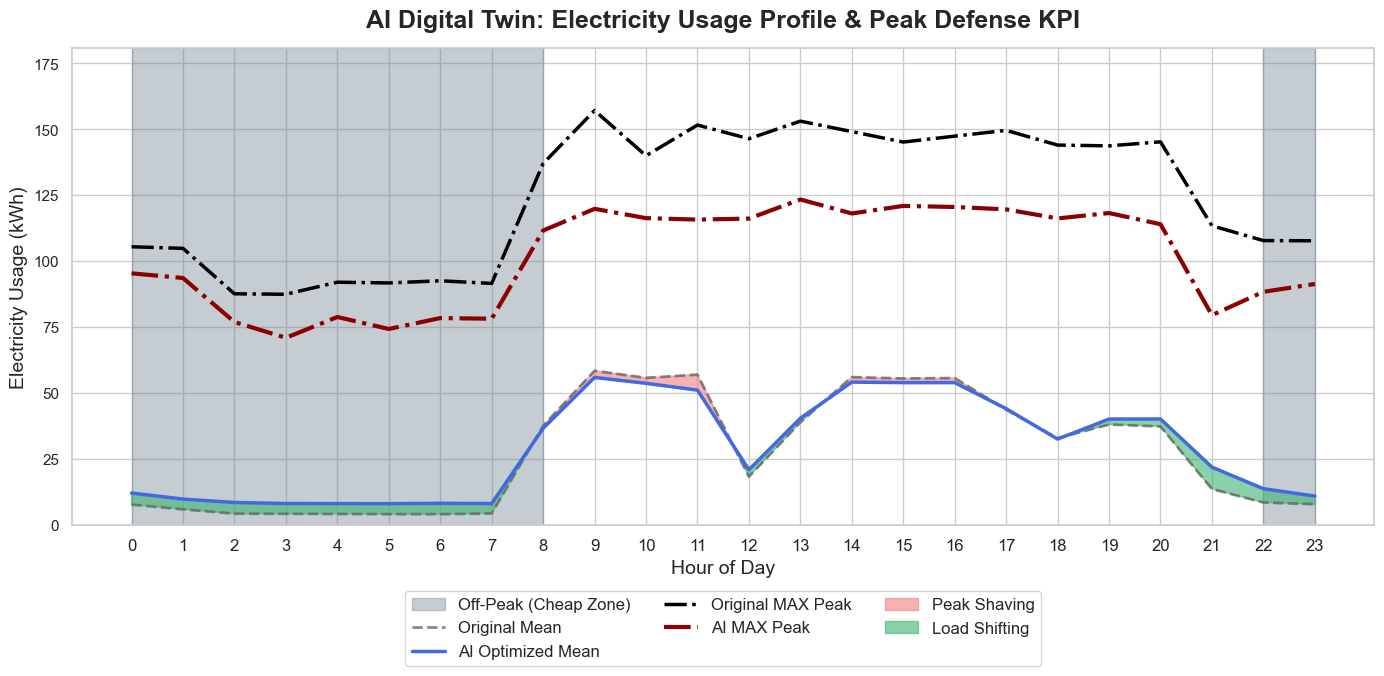

In [25]:
# [필수 검증] AI의 조업 패턴 및 생산량 방어 확인

# 1. 주/야간 가동률 쏠림 현상 점검
# (JSON 설정에 따라 야간 시간대 기준이 다를 수 있으나, 일반적으로 22시~08시 적용)
result_df = result_opt1
night_mask = result_df['Hour'].apply(lambda x: x >= 22 or x < 8)

day_avg_rate = result_df[~night_mask]['AI_Motor_Rate'].mean()
night_avg_rate = result_df[night_mask]['AI_Motor_Rate'].mean()

print("--- [시뮬레이션 결과 비판적 검증] ---")
print(f"1. 주간 평균 가동률: {day_avg_rate:.2f}%")
print(f"2. 야간 평균 가동률: {night_avg_rate:.2f}%")

# 야간에 100% 가까이 쏠려있고 주간이 0%에 가깝다면, labor_premium(야간 할증)을 더 높여야 합니다.

# 3. 조업 부채(Deficit) 해소 여부
final_deficit = result_df.iloc[-1]['Deficit_Status']
max_deficit = result_df['Deficit_Status'].max()

print(f"3. 시뮬레이션 기간 내 최대 조업 부채: {max_deficit:.2f}")
print(f"4. 1년 기말(최종) 누적 조업 부채: {final_deficit:.2f}")

plot_advanced_kpi_profile(df, result_df, tou_off_start=22, tou_off_end=8)

# 최종 부채가 0에 수렴하지 않고 크게 남아있다면, AI가 요금을 줄이겠다고 생산량을 희생시킨 '실패한 모델'입니다.

--- [시뮬레이션 결과 비판적 검증] ---
1. 주간 평균 가동률: 20.39%
2. 야간 평균 가동률: 7.38%
3. 시뮬레이션 기간 내 최대 조업 부채: 4.44
4. 1년 기말(최종) 누적 조업 부채: 0.16


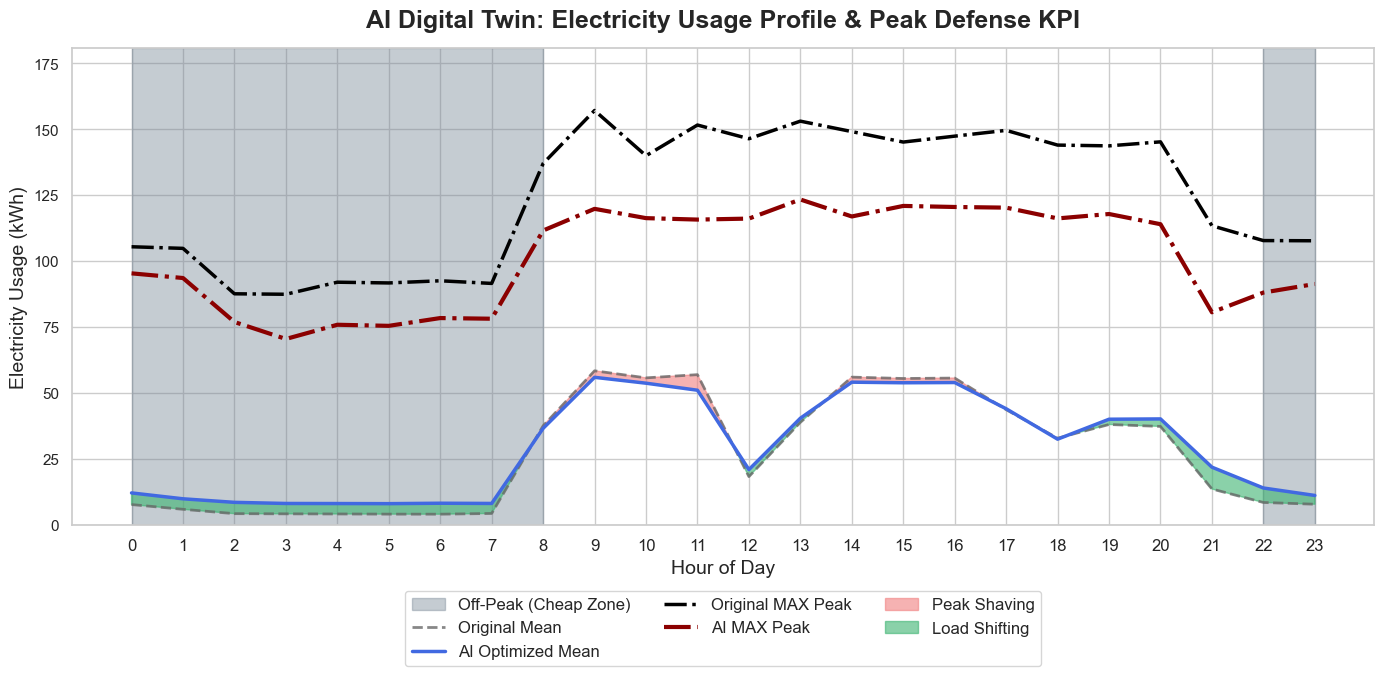

In [26]:
# [필수 검증] AI의 조업 패턴 및 생산량 방어 확인

# 1. 주/야간 가동률 쏠림 현상 점검
# (JSON 설정에 따라 야간 시간대 기준이 다를 수 있으나, 일반적으로 22시~08시 적용)
result_df = result_opt2
night_mask = result_df['Hour'].apply(lambda x: x >= 22 or x < 8)

day_avg_rate = result_df[~night_mask]['AI_Motor_Rate'].mean()
night_avg_rate = result_df[night_mask]['AI_Motor_Rate'].mean()

print("--- [시뮬레이션 결과 비판적 검증] ---")
print(f"1. 주간 평균 가동률: {day_avg_rate:.2f}%")
print(f"2. 야간 평균 가동률: {night_avg_rate:.2f}%")

# 야간에 100% 가까이 쏠려있고 주간이 0%에 가깝다면, labor_premium(야간 할증)을 더 높여야 합니다.

# 3. 조업 부채(Deficit) 해소 여부
final_deficit = result_df.iloc[-1]['Deficit_Status']
max_deficit = result_df['Deficit_Status'].max()

print(f"3. 시뮬레이션 기간 내 최대 조업 부채: {max_deficit:.2f}")
print(f"4. 1년 기말(최종) 누적 조업 부채: {final_deficit:.2f}")

plot_advanced_kpi_profile(df, result_df, tou_off_start=22, tou_off_end=8)

# 최종 부채가 0에 수렴하지 않고 크게 남아있다면, AI가 요금을 줄이겠다고 생산량을 희생시킨 '실패한 모델'입니다.

--- [시뮬레이션 결과 비판적 검증] ---
1. 주간 평균 가동률: 20.38%
2. 야간 평균 가동률: 7.39%
3. 시뮬레이션 기간 내 최대 조업 부채: 4.44
4. 1년 기말(최종) 누적 조업 부채: 0.16


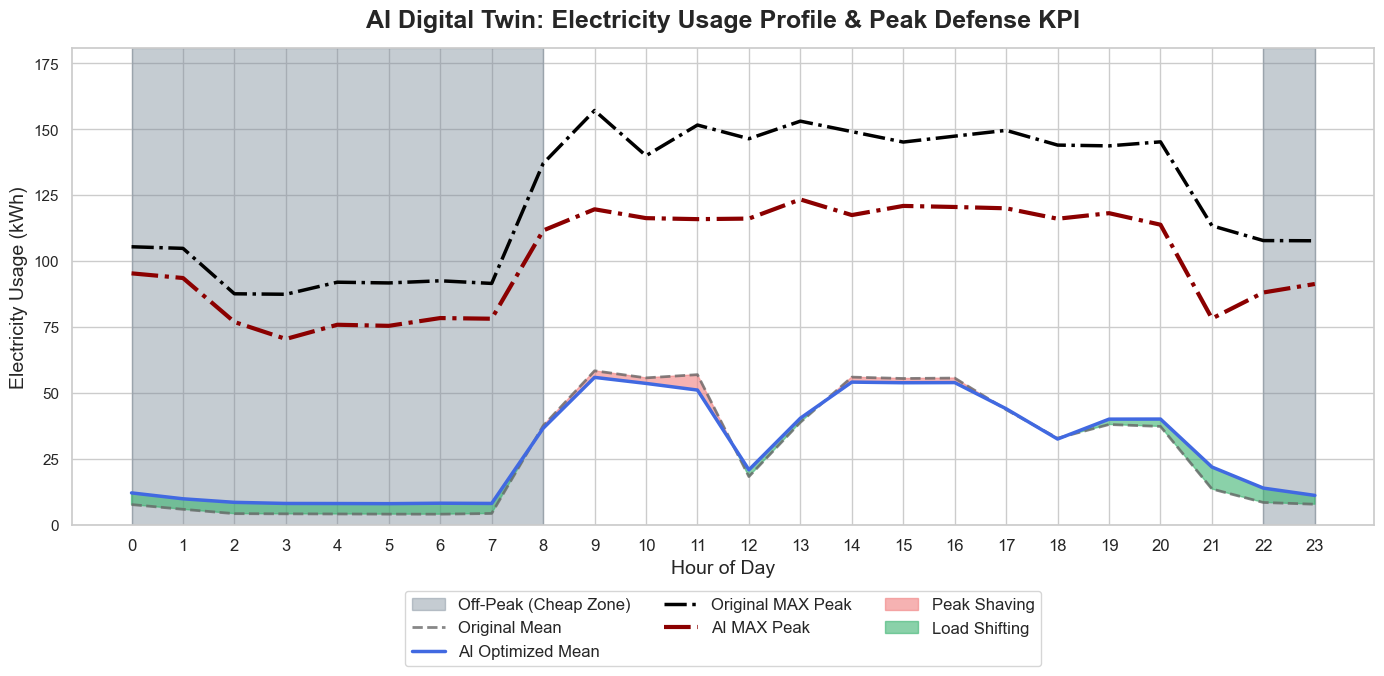

In [27]:
# [필수 검증] AI의 조업 패턴 및 생산량 방어 확인

# 1. 주/야간 가동률 쏠림 현상 점검
# (JSON 설정에 따라 야간 시간대 기준이 다를 수 있으나, 일반적으로 22시~08시 적용)
result_df = result_opt3
night_mask = result_df['Hour'].apply(lambda x: x >= 22 or x < 8)

day_avg_rate = result_df[~night_mask]['AI_Motor_Rate'].mean()
night_avg_rate = result_df[night_mask]['AI_Motor_Rate'].mean()

print("--- [시뮬레이션 결과 비판적 검증] ---")
print(f"1. 주간 평균 가동률: {day_avg_rate:.2f}%")
print(f"2. 야간 평균 가동률: {night_avg_rate:.2f}%")

# 야간에 100% 가까이 쏠려있고 주간이 0%에 가깝다면, labor_premium(야간 할증)을 더 높여야 합니다.

# 3. 조업 부채(Deficit) 해소 여부
final_deficit = result_df.iloc[-1]['Deficit_Status']
max_deficit = result_df['Deficit_Status'].max()

print(f"3. 시뮬레이션 기간 내 최대 조업 부채: {max_deficit:.2f}")
print(f"4. 1년 기말(최종) 누적 조업 부채: {final_deficit:.2f}")

plot_advanced_kpi_profile(df, result_df, tou_off_start=22, tou_off_end=8)

# 최종 부채가 0에 수렴하지 않고 크게 남아있다면, AI가 요금을 줄이겠다고 생산량을 희생시킨 '실패한 모델'입니다.

=== 💰 시나리오별 재무 성과 비교 (단위: 백만 원) ===


,Human_Total,AI_Total,Net_Elec_Savings,Extra_Labor,Final_Real_ROI
Scenario,,,,,
Option 1,137.43,139.02,-1.60,2.82,-4.41
Option 2,134.00,134.98,-0.98,2.86,-3.84
Option 3,131.70,132.26,-0.55,2.86,-3.41


<BarContainer object of 3 artists>

<BarContainer object of 3 artists>

Text(0, 0.5, 'Million KRW (백만 원)')

Text(0.5, 1.0, 'Financial ROI Comparison by Tariff Scenarios')

[Text(0, 0, 'Option 1'), Text(1, 0, 'Option 2'), Text(2, 0, 'Option 3')]

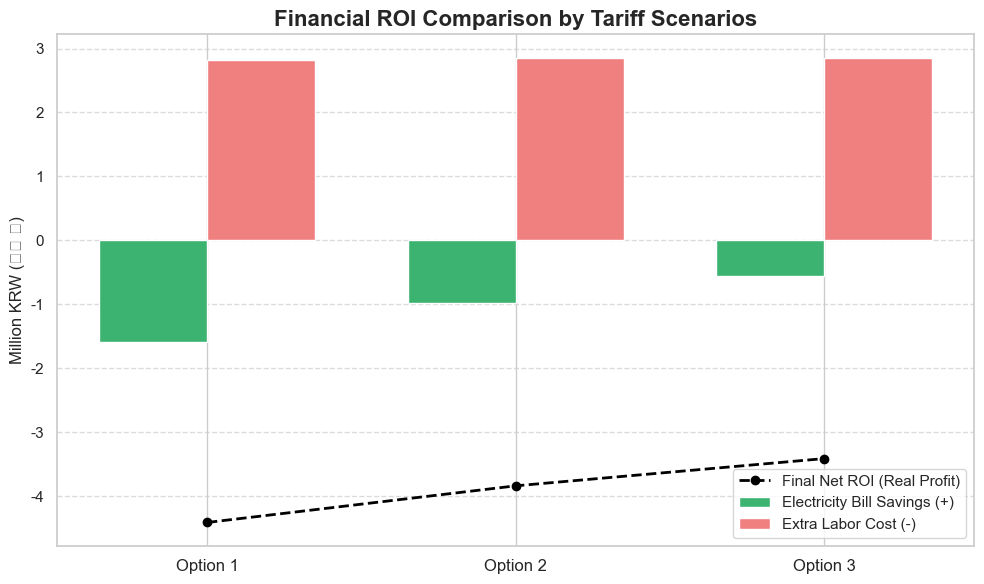

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

def calculate_financial_roi(df_result, scenario_config, labor_premium=50.0):
    """
    1년 치 시뮬레이션 결과를 바탕으로 한전 요금 체계를 모사하여 실제 청구 금액을 계산합니다.
    """
    base_rate = scenario_config['base_rate']
    
    # 1. 월별 기본요금 계산 (월 최대 피크 기준)
    # 한전 규정상 피크(kW)가 기준이지만, 1시간 단위 데이터이므로 kWh를 kW로 간주 (혹은 15분 단위라면 *4 필요)
    monthly_human_peak = df_result.groupby('Month')['Usage_kWh'].max()
    monthly_ai_peak = df_result.groupby('Month')['AI_Usage_kWh'].max()
    
    human_base_cost = (monthly_human_peak * base_rate).sum()
    ai_base_cost = (monthly_ai_peak * base_rate).sum()
    
    # 2. 전력량 요금 계산 (시간대별 단가 적용)
    # 기존 코드에서 사용한 get_current_unit_price 함수 로직이 반영되었다고 가정하고,
    # 여기서는 결과 데이터프레임의 Cost를 역산하거나 단순화하여 산출합니다.
    # (이미 비용 계산 시 'effective_price'를 적용했으나, 순수 전기료 분리를 위해 재계산)
    
    def get_price(row):
        season = 'summer' if row['Month'] in [6,7,8] else 'winter' if row['Month'] in [11,12,1,2] else 'spring_fall'
        schedule = scenario_config['tou_schedule'][season]
        prices = scenario_config['unit_prices'][season]
        
        for t_type, times in schedule.items():
            for s, e in times:
                if s > e: # 야간 자정 넘어가는 경우
                    if row['Hour'] >= s or row['Hour'] < e: return prices[t_type], t_type
                else:
                    if s <= row['Hour'] < e: return prices[t_type], t_type
        return prices['off'], 'off'

    # 단가 및 시간대 판별 적용
    df_result[['Unit_Price', 'TOU_Type']] = df_result.apply(
        lambda x: pd.Series(get_price(x)), axis=1
    )
    
    human_energy_cost = (df_result['Usage_kWh'] * df_result['Unit_Price']).sum()
    ai_energy_cost = (df_result['AI_Usage_kWh'] * df_result['Unit_Price']).sum()
    
    # 3. 추가 인건비 계산 (야간 시간대에 AI가 인간보다 조업을 더 한 경우)
    night_mask = df_result['TOU_Type'] == 'off'
    ai_extra_night_usage = np.maximum(0, df_result.loc[night_mask, 'AI_Usage_kWh'] - df_result.loc[night_mask, 'Usage_kWh'])
    extra_labor_cost = (ai_extra_night_usage * labor_premium).sum()
    
    # 4. 역률(PF) 패널티 계산 (90% 미만 시 페널티 부과)
    # 한전 기준: 90% 미만 매 1%당 기본요금의 0.2% 할증 (간소화 적용)
    human_pf_penalty = df_result[df_result['PF_Physical'] < 90]['Usage_kWh'].sum() * 10 # 가상의 페널티 단가
    ai_pf_penalty = df_result[df_result['AI_PF'] < 90]['AI_Usage_kWh'].sum() * 10
    
    # 총계
    human_total_bill = human_base_cost + human_energy_cost + human_pf_penalty
    ai_total_bill = ai_base_cost + ai_energy_cost + ai_pf_penalty
    
    net_savings = human_total_bill - ai_total_bill
    real_roi = net_savings - extra_labor_cost # 인건비 고려 최종 수익
    
    return {
        'Human_Base': human_base_cost, 'AI_Base': ai_base_cost,
        'Human_Energy': human_energy_cost, 'AI_Energy': ai_energy_cost,
        'Human_Total': human_total_bill, 'AI_Total': ai_total_bill,
        'Extra_Labor': extra_labor_cost,
        'Net_Elec_Savings': net_savings,
        'Final_Real_ROI': real_roi
    }

# --- 시나리오별 평가 실행 ---
# (앞서 실행하신 result_opt1, result_opt2, result_opt3 객체가 메모리에 있다고 가정)
with open('electricity_config_master.json', 'r', encoding='utf-8') as f:
    master_config = json.load(f)

# 실제 실행된 데이터프레임 이름에 맞게 수정해주세요 (예: result_opt1, result_opt2, result_opt3)
results_dict = {
    'Option 1': (result_opt1, master_config['scenarios']['2018_industrial_HV_A_opt1']),
    'Option 2': (result_opt2, master_config['scenarios']['2018_industrial_HV_A_opt2']),
    'Option 3': (result_opt3, master_config['scenarios']['2018_industrial_HV_A_opt3'])
}

summary_data = []
for name, (df_res, config) in results_dict.items():
    # labor_premium은 방금 전 시뮬레이션에서 사용했던 값(예: 10.0 또는 50.0)과 동일하게 맞추십시오.
    roi = calculate_financial_roi(df_res, config, labor_premium=50.0) 
    roi['Scenario'] = name
    summary_data.append(roi)

df_summary = pd.DataFrame(summary_data).set_index('Scenario')

# 금액 단위 변환 (원 -> 백만 원)
df_summary = df_summary / 1_000_000

print("=== 💰 시나리오별 재무 성과 비교 (단위: 백만 원) ===")
display(df_summary[['Human_Total', 'AI_Total', 'Net_Elec_Savings', 'Extra_Labor', 'Final_Real_ROI']].round(2))

# --- 시각화 ---
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(df_summary.index))
width = 0.35

ax.bar(x - width/2, df_summary['Net_Elec_Savings'], width, label='Electricity Bill Savings (+)', color='mediumseagreen')
ax.bar(x + width/2, df_summary['Extra_Labor'], width, label='Extra Labor Cost (-)', color='lightcoral')

# 진짜 순수익(점선) 표시
ax.plot(x, df_summary['Final_Real_ROI'], marker='o', color='black', linewidth=2, linestyle='--', label='Final Net ROI (Real Profit)')

ax.set_ylabel('Million KRW (백만 원)', fontsize=12)
ax.set_title('Financial ROI Comparison by Tariff Scenarios', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_summary.index, fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_kepco_pf_defense(df_result):
    """
    한전의 실제 역률 규정(시간대별 지상/진상 분리)을 적용하여 AI의 제어 결과를 검증합니다.
    (스케일: 0.0 ~ 1.0 반영)
    """
    df = df_result.copy()
    time_col = 'hour' if 'hour' in df.columns else 'Hour'
    
    # 낮(지상) / 밤(진상) 마스크 생성
    day_mask = (df[time_col] >= 9) & (df[time_col] < 23)
    night_mask = ~day_mask
    
    # 1. Original (Human) 페널티 계산 (지상 0.9, 진상 0.95 미만)
    human_day_penalty = df[day_mask & (df['PF_Physical'] < 0.9)]
    human_night_penalty = df[night_mask & (df['PF_Physical'] < 0.95)]
    
    # 2. AI 최적화 페널티 계산
    ai_day_penalty = df[day_mask & (df['AI_PF'] < 0.9)]
    ai_night_penalty = df[night_mask & (df['AI_PF'] < 0.95)]
    
    print("=== 🛡️ 한전 기준(지상/진상) 역률 방어율 정밀 검증 ===")
    print("[Original - 인간 제어]")
    print(f" ├─ 주간(지상 < 0.90) 페널티: {len(human_day_penalty):,d}시간")
    print(f" └─ 야간(진상 < 0.95) 페널티: {len(human_night_penalty):,d}시간")
    print("[AI - 디지털 트윈 제어]")
    print(f" ├─ 주간(지상 < 0.90) 페널티: {len(ai_day_penalty):,d}시간")
    print(f" └─ 야간(진상 < 0.95) 페널티: {len(ai_night_penalty):,d}시간")

    # 3. 고도화된 시각화 (KDE Plot with 2 Thresholds)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    sns.set_style("whitegrid")
    
    # --- (1) 주간 지상역률 분포 (09:00 ~ 23:00) ---
    sns.kdeplot(data=df[day_mask], x='PF_Physical', color='grey', fill=True, alpha=0.3, label='Original PF', ax=axes[0])
    sns.kdeplot(data=df[day_mask], x='AI_PF', color='royalblue', fill=True, alpha=0.4, label='AI PF', ax=axes[0])
    
    axes[0].axvline(x=0.9, color='red', linestyle='--', linewidth=2, label='Lagging Threshold (0.90)')
    # 음영 표시 영역도 0~1 스케일에 맞게 미세 조정 (-0.05)
    axes[0].axvspan(df['AI_PF'].min() - 0.05, 0.9, color='lightcoral', alpha=0.2, label='Penalty Zone')
    
    axes[0].set_title('Daytime Lagging PF (09:00~23:00)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Power Factor', fontsize=12)
    
    # X축 범위를 0~1.05 사이로 제한 (너무 튀는 이상치 방지)
    pf_min_day = min(df.loc[day_mask, 'PF_Physical'].min(), df.loc[day_mask, 'AI_PF'].min())
    axes[0].set_xlim(max(0, pf_min_day - 0.05), 1.05)
    axes[0].legend()

    # --- (2) 야간 진상역률 분포 (23:00 ~ 09:00) ---
    sns.kdeplot(data=df[night_mask], x='PF_Physical', color='grey', fill=True, alpha=0.3, label='Original PF', ax=axes[1])
    sns.kdeplot(data=df[night_mask], x='AI_PF', color='darkorange', fill=True, alpha=0.4, label='AI PF', ax=axes[1])
    
    axes[1].axvline(x=0.95, color='darkred', linestyle='--', linewidth=2, label='Leading Threshold (0.95)')
    axes[1].axvspan(df['AI_PF'].min() - 0.05, 0.95, color='lightcoral', alpha=0.2, label='Penalty Zone')
    
    axes[1].set_title('Nighttime Leading PF (23:00~09:00)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Power Factor', fontsize=12)
    
    pf_min_night = min(df.loc[night_mask, 'PF_Physical'].min(), df.loc[night_mask, 'AI_PF'].min())
    axes[1].set_xlim(max(0, pf_min_night - 0.05), 1.05)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# 실행:


=== 🛡️ 한전 기준(지상/진상) 역률 방어율 정밀 검증 ===
[Original - 인간 제어]
 ├─ 주간(지상 < 0.90) 페널티: 12,042시간
 └─ 야간(진상 < 0.95) 페널티: 14,576시간
[AI - 디지털 트윈 제어]
 ├─ 주간(지상 < 0.90) 페널티: 5,146시간
 └─ 야간(진상 < 0.95) 페널티: 13,632시간


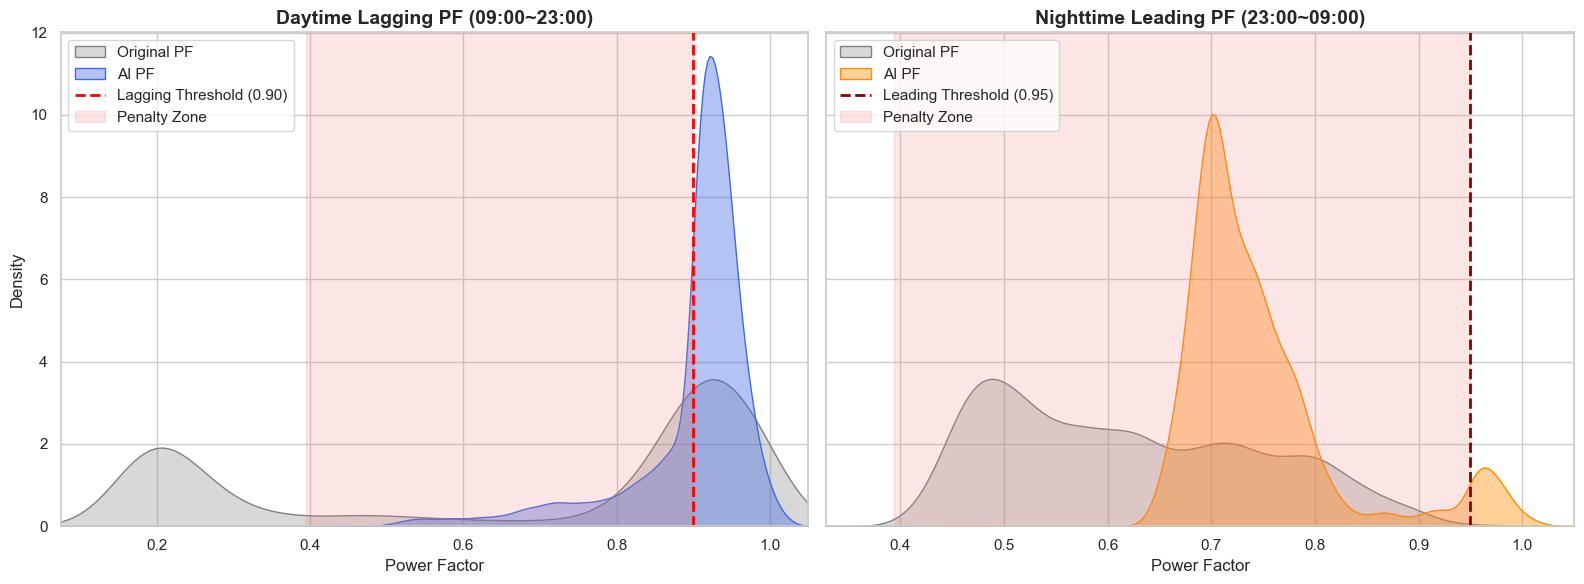

In [30]:
# --- 실행 방법 ---
# 가장 수익성이 좋았던 Option 3의 결과를 넣고 검증합니다.
analyze_kepco_pf_defense(result_opt3)

In [31]:
import pandas as pd
import numpy as np

def calculate_monthly_kepco_pf_penalty(df_result, scenario_config):
    """
    JSON 설정에 따라 90%(과거) 또는 92%(최신) 기준을 자동으로 선택하여 채점합니다.
    (스케일: 역률 0.0 ~ 1.0 적용)
    """
    pf_logic = scenario_config.get('pf_logic', {})
    lag_target_pct = pf_logic.get('lag_target', 90)     
    lead_target_pct = pf_logic.get('lead_target', 95)  
    lag_start = pf_logic.get('lag_start', 9)            
    lag_end = pf_logic.get('lag_end', 23)               

    df = df_result.copy()
    time_col = 'hour' if 'hour' in df.columns else 'Hour'
    
    # 지상/진상 시간대 분리 (JSON 기준)
    day_mask = (df[time_col] >= lag_start) & (df[time_col] < lag_end)
    night_mask = ~day_mask
    
    # 역률 안전장치 (0으로 나누기 방지 및 1 초과 방지)
    df['PF_Physical'] = np.clip(df['PF_Physical'], 0.01, 1.0)
    df['AI_PF'] = np.clip(df['AI_PF'], 0.01, 1.0)
    
    # 무효전력량(kVarh) 역산 수식: kVarh = kWh * tan(arccos(PF))
    df['Human_kVarh'] = df['Usage_kWh'] * np.tan(np.arccos(df['PF_Physical']))
    df['AI_kVarh'] = df['AI_Usage_kWh'] * np.tan(np.arccos(df['AI_PF']))
    
    # 결과를 담을 리스트
    monthly_results = []
    
    for month, group in df.groupby('Month'):
        # --- [주간/지상역률 계산] ---
        day_group = group[day_mask.loc[group.index]]
        sum_p_day_h = day_group['Usage_kWh'].sum()
        sum_q_day_h = day_group['Human_kVarh'].sum()
        human_lag_pf = sum_p_day_h / np.sqrt(sum_p_day_h**2 + sum_q_day_h**2) if sum_p_day_h > 0 else 1.0
        
        sum_p_day_ai = day_group['AI_Usage_kWh'].sum()
        sum_q_day_ai = day_group['AI_kVarh'].sum()
        ai_lag_pf = sum_p_day_ai / np.sqrt(sum_p_day_ai**2 + sum_q_day_ai**2) if sum_p_day_ai > 0 else 1.0
        
        # --- [야간/진상역률 계산] ---
        night_group = group[night_mask.loc[group.index]]
        sum_p_night_h = night_group['Usage_kWh'].sum()
        sum_q_night_h = night_group['Human_kVarh'].sum()
        human_lead_pf = sum_p_night_h / np.sqrt(sum_p_night_h**2 + sum_q_night_h**2) if sum_p_night_h > 0 else 1.0
        
        sum_p_night_ai = night_group['AI_Usage_kWh'].sum()
        sum_q_night_ai = night_group['AI_kVarh'].sum()
        ai_lead_pf = sum_p_night_ai / np.sqrt(sum_p_night_ai**2 + sum_q_night_ai**2) if sum_p_night_ai > 0 else 1.0
        
        # --- [페널티 산정 로직] ---
        def calc_lag_penalty(pf):
            pf_pct = np.floor(pf * 100)
            if pf_pct < lag_target_pct: return (lag_target_pct - pf_pct) * 0.2 # 페널티 (+)
            elif lag_target_pct <= pf_pct <= 95: return (lag_target_pct - pf_pct) * 0.2 # 할인 (-)
            else: return -1.0 if pf_pct > 95 else 0.0 # 최대 할인 한도 1% (95% 초과 시 고정)
        
        # 진상(밤): 95% 기준 (1%당 0.2% 페널티, 할인은 없음)        
        def calc_lead_penalty(pf):
            pf_pct = np.floor(pf * 100)
            if pf_pct < lead_target_pct: return (lead_target_pct - pf_pct) * 0.2 # 페널티 (+)
            return 0.0
            
        h_penalty = calc_lag_penalty(human_lag_pf) + calc_lead_penalty(human_lead_pf)
        ai_penalty = calc_lag_penalty(ai_lag_pf) + calc_lead_penalty(ai_lead_pf)
        
        monthly_results.append({
            'Month': month,
            'Human_Lag_PF(%)': round(human_lag_pf * 100, 2),
            'AI_Lag_PF(%)': round(ai_lag_pf * 100, 2),
            'Human_Lead_PF(%)': round(human_lead_pf * 100, 2),
            'AI_Lead_PF(%)': round(ai_lead_pf * 100, 2),
            'Human_BaseRate_Adj(%)': round(h_penalty, 2),
            'AI_BaseRate_Adj(%)': round(ai_penalty, 2)
        })

    result_df = pd.DataFrame(monthly_results).set_index('Month')
    print("=== 📅 한전 청구 기준 월별 역률 및 기본요금 증감률 ===")
    print("* BaseRate_Adj(%): 양수(+)는 페널티 부과, 음수(-)는 요금 할인 의미")
    display(result_df)
    
    return result_df

In [33]:
# 실행 방법
kepco_pf_report = calculate_monthly_kepco_pf_penalty(result_opt3, master_config['scenarios']['2018_industrial_HV_A_opt3'])

=== 📅 한전 청구 기준 월별 역률 및 기본요금 증감률 ===
* BaseRate_Adj(%): 양수(+)는 페널티 부과, 음수(-)는 요금 할인 의미


,Human_Lag_PF(%),AI_Lag_PF(%),Human_Lead_PF(%),AI_Lead_PF(%),Human_BaseRate_Adj(%),AI_BaseRate_Adj(%)
Month,,,,,,
1,90.49,94.68,81.60,91.60,2.8,0.0
2,90.69,94.44,81.63,91.52,2.8,0.0
3,89.56,93.76,74.20,83.30,4.4,1.8
4,88.26,93.34,71.23,82.16,5.2,2.0
5,86.37,92.42,66.60,77.81,6.6,3.2
6,85.33,91.39,63.13,75.68,7.4,3.8
7,88.16,91.02,66.42,77.43,6.2,3.4
8,84.17,91.49,61.61,73.72,8.0,4.2
9,83.72,90.81,59.60,74.72,8.6,4.2
